In [14]:
# --- Clean & pin a compatible Zarr stack for Colab (Py 3.12) ---
!pip -q uninstall -y zarr numcodecs blosc python-blosc
!pip -q install "zarr==2.17.2" "numcodecs==0.12.1" "xarray>=2024.2.0" \
                "fsspec>=2023.6.0" "gcsfs>=2023.6.0" "intake-esm>=2024.2.10" \
                "cftime" "h5netcdf" "netCDF4" "cartopy" "regionmask"

# Hard restart so compiled extensions (numcodecs.blosc) reload cleanly
import IPython
IPython.display.clear_output(wait=True)
print("Rebooting kernel to finalize installs...")
IPython.get_ipython().kernel.do_shutdown(True)



Rebooting kernel to finalize installs...


{'status': 'ok', 'restart': True}

In [15]:
import xarray as xr, zarr
from numcodecs import blosc as nblosc
print("zarr:", zarr.__version__)
print("numcodecs blosc:", getattr(nblosc, "BLOSC_VERSION_STRING", "OK"))
print("engines:", xr.backends.list_engines())
assert "zarr" in xr.backends.list_engines()

import os, numpy as np, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
import intake

# mount Drive for input/output
from google.colab import drive
drive.mount('/content/drive')

WORKDIR = "/content/drive/MyDrive/climate_work"   # change if needed
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{OUTDIR}/output_maps"
os.makedirs(PLOTDIR, exist_ok=True)

print("WORKDIR:", WORKDIR)
print("OUTDIR :", OUTDIR)
print("PLOTDIR:", PLOTDIR)


zarr: 2.17.2
numcodecs blosc: OK
engines: {'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'h5netcdf': <H5netcdfBackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .cdf and .nc.gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'pydap': <PydapBackendEntrypoint>
  Open remote datasets via OPeNDAP using pydap in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.PydapBackendEntrypoint.html, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://do

In [3]:
!pip -q install "intake-esm>=2024.2.10" "gcsfs>=2023.6.0" "cftime" "h5netcdf" "netCDF4" "cartopy"



In [ ]:
# Open multiple files with chunking to handle large datasets
chunks = {"time": 365}  # tune if you want
ds = xr.open_mfdataset(inputs, combine="by_coords", parallel=True, chunks=chunks)

# Pick a variable (auto-detect, or set varname = "tmax" if you prefer)
varname = find_data_var(ds)
print("Using variable:", varname)
da = ds[varname]

# Kelvin -> °C if needed
units = da.attrs.get("units", "").lower()
if units in ["k", "kelvin"] or (float(da.max()) > 200 and float(da.min()) > 150):
    print("[info] Converting Kelvin to degC.")
    da = da - 273.15
    da.attrs["units"] = "degree_Celsius"

# (Optional) add climatology if your inputs are anomalies.
# If you have one, point clim_path to it; else leave as None and it will skip.
clim_path = None  # e.g., f"{WORKDIR}/TMAX_climatology.nc"
clim_ds = xr.open_dataset(clim_path) if clim_path else None
da = add_climatology_if_needed(da, clim_ds)

# Subset to 1990–2014 (full globe; you can subset lat/lon later for plotting)
ds_sub = subset_1990_2014(da.to_dataset(name=varname))
da_sub = ds_sub[varname]

# Compute percentiles
pct = compute_percentiles(da_sub, q_list=(0.90, 0.98, 0.99))
pct.attrs.update(da_sub.attrs)

# Save to Drive (OUTDIR)
base_name = varname if varname != "temperature" else "tmax"
save_percentiles(pct, OUTDIR, base_name=base_name)

In [ ]:
CANDIDATE_VARS = [
    "tmax", "tasmax", "TMAX", "tx", "TX", "temperature"  # 'temperature' often in Berkeley anomaly files
]

def find_data_var(ds):
    for name in CANDIDATE_VARS:
        if name in ds.data_vars:
            return name
    for name, da in ds.data_vars.items():
        if "time" in da.dims and np.issubdtype(da.dtype, np.floating):
            return name
    raise ValueError("Could not find a Tmax-like variable. Checked: " + ", ".join(CANDIDATE_VARS))

def add_climatology_if_needed(da, clim_ds=None):
    # Heuristic: anomalies tend to sit within ~±25°C
    vmin = float(da.min())
    vmax = float(da.max())
    likely_anomaly = (vmin > -50) and (vmax < 50) and (abs(vmin) < 25 and abs(vmax) < 25)
    if likely_anomaly and clim_ds is not None:
        print("[info] Adding climatology to anomaly field to obtain absolute Tmax.")
        clim_vars = ["climatology", "tmax_climatology", "TMAX_climatology", "tmax_clim", "clim"]
        clim_var = next((v for v in clim_vars if v in clim_ds.data_vars), None)
        if clim_var is None:
            non_coord = [k for k in clim_ds.data_vars]
            clim_var = non_coord[0] if len(non_coord) == 1 else None
        if clim_var is None:
            print("[warn] Could not auto-detect a climatology variable; proceeding without it.")
            return da
        clim = clim_ds[clim_var]
        if "time" in clim.dims and "time" in da.dims:
            clim = clim.sel(time=da.time)
        elif "dayofyear" in clim.dims and "time" in da.dims:
            doy = xr.DataArray(da["time"].dt.dayofyear, dims=("time",), coords={"time": da["time"]})
            clim = clim.sel(dayofyear=doy)
        return da + clim
    return da

def ensure_time(ds):
    if "time" in ds.coords:
        return ds
    if "year" in ds.coords:
        print("[warn] No 'time' coord found; using 'year' to create a pseudo-time.")
        time = xr.cftime_range(start=f"{int(ds.year.min())}-07-01", periods=ds.sizes["year"], freq="AS-JUL")
        return ds.assign_coords(time=("year", time))
    raise ValueError("Dataset lacks a 'time' or 'year' coordinate; cannot filter to 1990–2014.")

def subset_1990_2014(ds):
    ds = ensure_time(ds)
    return ds.sel(time=slice("1990-01-01", "2014-12-31"))

def compute_percentiles(da, q_list=(0.90, 0.98, 0.99)):
    qs = xr.DataArray(list(q_list), dims="quantile", coords={"quantile": list(q_list)})
    pct = da.quantile(q=qs, dim="time", skipna=True, keep_attrs=True)
    return pct

def save_percentiles(pct_da, outdir, base_name="tmax"):
    os.makedirs(outdir, exist_ok=True)
    mapping = {"0.90": "90", "0.98": "98", "0.99": "99"}
    for q_val in pct_da.quantile.values:
        q_str = f"{q_val:.2f}"
        tag = mapping.get(q_str, q_str.replace(".", ""))
        varname = f"{base_name}_{tag}th_percentile"
        out_path = os.path.join(outdir, f"{base_name}_{tag}th_percentile.nc")
        ds_out = xr.Dataset({varname: pct_da.sel(quantile=q_val).drop_vars("quantile", errors="ignore")})
        ds_out[varname].attrs["long_name"] = f"{base_name.upper()} {int(float(tag))}th percentile (1990–2014)"
        if "units" in pct_da.attrs:
            ds_out[varname].attrs["units"] = pct_da.attrs["units"]
        ds_out.to_netcdf(out_path)
        print("[saved]", out_path)


In [ ]:
# EDIT these to wherever your files live in Drive:
base_name = "tmax"  # change if your variable is named differently in the files

percentile_files = {
    "percentile_90": f"{OUTDIR}/{base_name}_90th_percentile.nc",
    "percentile_98": f"{OUTDIR}/{base_name}_98th_percentile.nc",
    "percentile_99": f"{OUTDIR}/{base_name}_99th_percentile.nc",
}

percentile_files


{'percentile_90': '/content/drive/MyDrive/climate_work/historical_output/tmax_90th_percentile.nc',
 'percentile_98': '/content/drive/MyDrive/climate_work/historical_output/tmax_98th_percentile.nc',
 'percentile_99': '/content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc'}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WORKDIR: /content/drive/MyDrive/climate_work
OUTDIR : /content/drive/MyDrive/climate_work/historical_output
PLOTDIR: /content/drive/MyDrive/climate_work/historical_output/output_maps
Berkeley files: {90: '/content/drive/MyDrive/climate_work/historical_output/tmax_90th_percentile.nc', 98: '/content/drive/MyDrive/climate_work/historical_output/tmax_98th_percentile.nc', 99: '/content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc'}

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:15&lt;00:00]</div>

[info] Loaded via intake; found 1 dataset(s)

--- Debug 90th ---
Berkeley units: Not specified
Berkeley range: 9.054685828089713 .. 46.780989331007
Model units   : degree_Celsius
Model range   : 2.3057678222656257 .. 47.40567830403646


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p90_berkeley.png


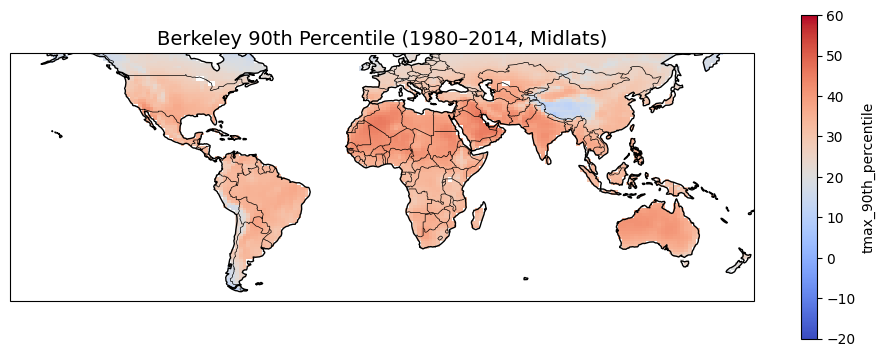

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p90_model.png


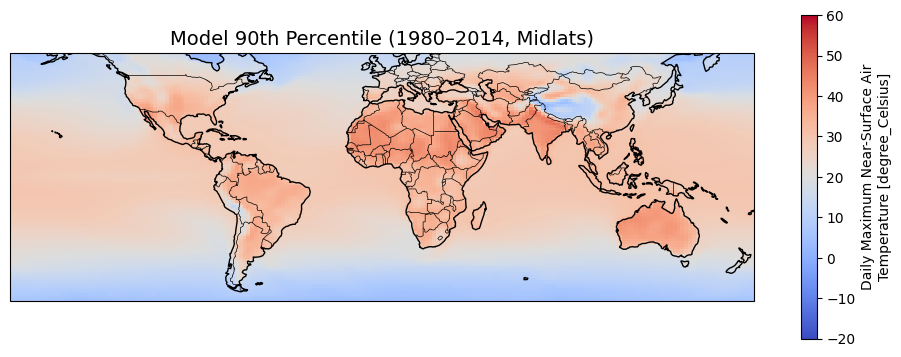

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p90_difference.png


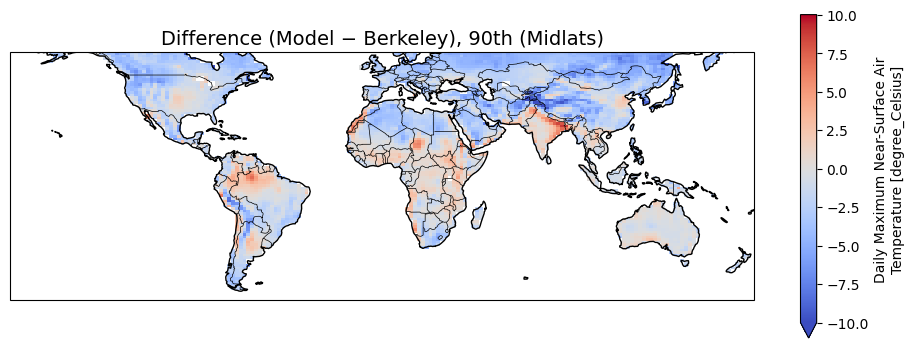


--- Debug 98th ---
Berkeley units: Not specified
Berkeley range: 10.86110736370086 .. 48.73662277340889
Model units   : degree_Celsius
Model range   : 4.104219970703125 .. 49.48416625976562
Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p98_berkeley.png


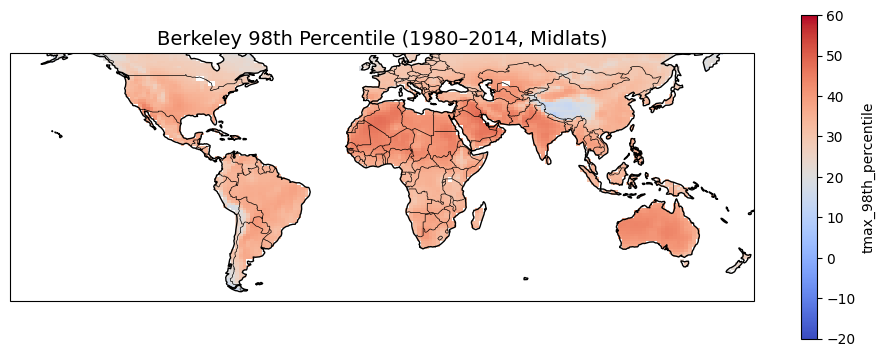

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p98_model.png


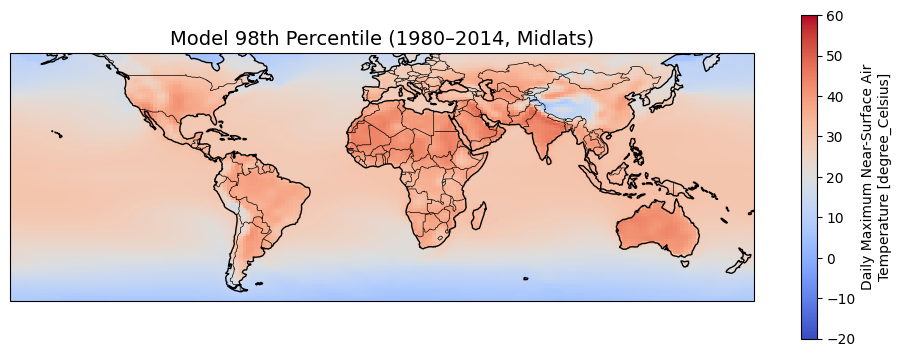

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p98_difference.png


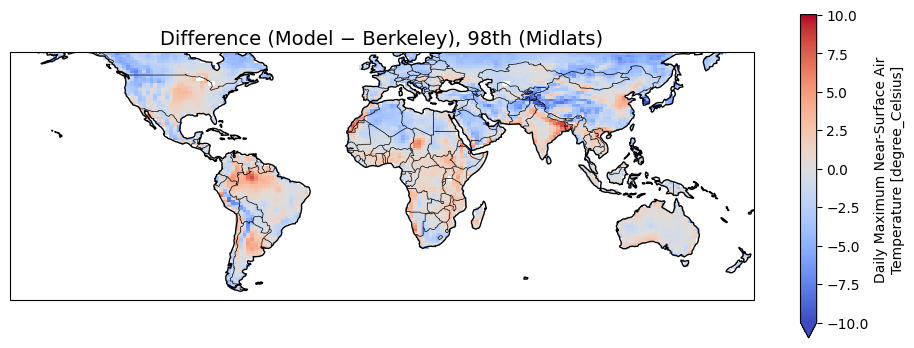


--- Debug 99th ---
Berkeley units: Not specified
Berkeley range: 11.487157442271716 .. 49.29302765011788
Model units   : degree_Celsius
Model range   : 4.643407796223959 .. 50.070740966796876
Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p99_berkeley.png


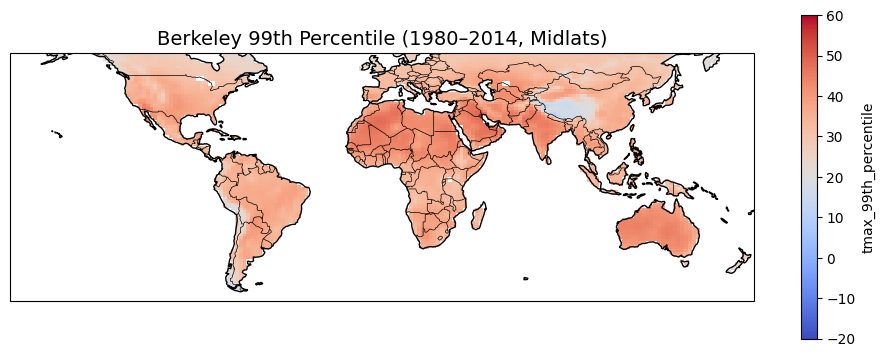

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p99_model.png


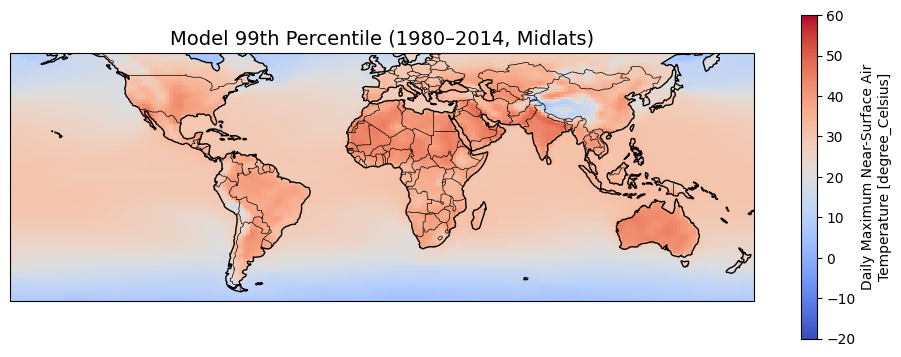

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p99_difference.png


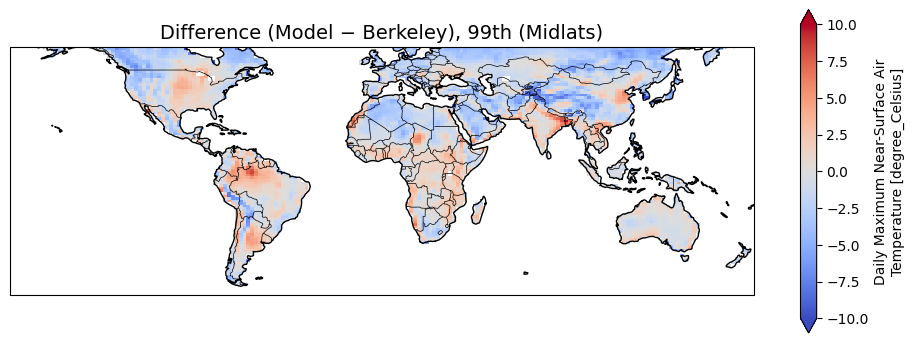


[done] All percentile comparisons saved in: /content/drive/MyDrive/climate_work/historical_output/output_maps


In [ ]:
# ===============================================
# Model (90/98/99) vs Berkeley (90/98/99) percentiles
# ===============================================

# --- Imports & Drive setup ---
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake

from google.colab import drive
drive.mount('/content/drive')

# --- Paths (edit if needed) ---
WORKDIR = "/content/drive/MyDrive/climate_work"
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{OUTDIR}/output_maps"
os.makedirs(PLOTDIR, exist_ok=True)

# Berkeley percentile files (already computed)
base_name = "tmax"  # change if your variable in the files is named differently
percentile_files = {
    90: f"{OUTDIR}/{base_name}_90th_percentile.nc",
    98: f"{OUTDIR}/{base_name}_98th_percentile.nc",
    99: f"{OUTDIR}/{base_name}_99th_percentile.nc",
}

print("WORKDIR:", WORKDIR)
print("OUTDIR :", OUTDIR)
print("PLOTDIR:", PLOTDIR)
print("Berkeley files:", percentile_files)

# --- Pull model tasmax from CMIP6 zarr catalog ---
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
cat = col.search(
    source_id="ACCESS-CM2",
    experiment_id="historical",
    table_id="day",
    variable_id="tasmax",
    # For reproducibility you can pin these:
    # member_id="r1i1p1f1", grid_label="gn",
)

try:
    dsets = cat.to_dataset_dict(
        zarr_kwargs={"consolidated": True, "use_cftime": True},
        storage_options={"token": "anon"},
    )
    print(f"[info] Loaded via intake; found {len(dsets)} dataset(s)")
    ds_model = list(dsets.values())[0]
except Exception as e:
    print("[warn] intake failed; falling back to direct open_zarr:", e)
    df = cat.df[["member_id","grid_label","zstore"]].drop_duplicates().sort_values(["member_id","grid_label"]).reset_index(drop=True)
    zurl = df.iloc[0]["zstore"]
    ds_model = xr.open_zarr(zurl, consolidated=True, storage_options={"token": "anon"})

# Standardize longitude to [-180, 180] and sort
if ds_model["lon"].max() > 180:
    ds_model = ds_model.assign_coords(lon=((ds_model["lon"] + 180) % 360) - 180)
ds_model = ds_model.sortby("lon")

# --- Subset 1980–2014 and convert Kelvin→°C if needed ---
tas = ds_model["tasmax"].sel(time=slice("1980-01-01", "2014-12-31"))
units = tas.attrs.get("units", "").lower()
if units in ["k", "kelvin"] or (float(tas.max()) > 200 and float(tas.min()) > 150):
    tas = tas - 273.15
    tas.attrs["units"] = "degree_Celsius"

# --- Compute model's percentiles (per grid cell over time) ---
Q_LIST = [0.90, 0.98, 0.99]
qs = xr.DataArray(Q_LIST, dims="quantile", coords={"quantile": Q_LIST})
model_pct_all = tas.quantile(q=qs, dim="time", skipna=True, keep_attrs=True)  # dims: quantile, lat, lon
model_pct_all.attrs.update(tas.attrs)

# --- Helpers: ensure 2D (lat,lon), plotting, debugging ---
def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    """Force a true 2D (lat, lon) field:
       - convert Datasets to DataArrays
       - normalize coord names (latitude/longitude → lat/lon)
       - squeeze singletons
       - average any leftover non-(lat,lon) dims
       - sort latitude ascending
    """
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray):
        da = xr.DataArray(da)

    ren = {}
    if "latitude" in da.dims: ren["latitude"] = "lat"
    if "longitude" in da.dims: ren["longitude"] = "lon"
    if ren:
        da = da.rename(ren)

    da = da.squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat", "lon")]
    if extra:
        da = da.mean(dim=extra, keep_attrs=True)

    if "lat" in da.dims and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")

    return da

def plot_map(data, title, vmin=None, vmax=None, save_path=None):
    da = to_latlon_2d(data).astype("float64")
    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -60, 60], crs=ccrs.PlateCarree())
    da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
        vmin=vmin, vmax=vmax,
        add_colorbar=True, cbar_kwargs={"shrink": 0.7},
    )
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title, fontsize=14)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show(); plt.close()

def debug_units_and_ranges(berkeley_data, model_data, tag):
    bd = to_latlon_2d(berkeley_data)
    md = to_latlon_2d(model_data)
    print(f"\n--- Debug {tag} ---")
    print(f"Berkeley units: {bd.attrs.get('units', 'Not specified')}")
    print(f"Berkeley range: {float(bd.min())} .. {float(bd.max())}")
    print(f"Model units   : {md.attrs.get('units', 'Not specified')}")
    print(f"Model range   : {float(md.min())} .. {float(md.max())}")

# --- Loop over 90/98/99 percentiles ---
for q in [90, 98, 99]:
    qf = q / 100.0

    # Model percentile (2D), midlats
    model_q = model_pct_all.sel(quantile=qf).drop_vars("quantile", errors="ignore")
    model_q_mid = model_q.sel(lat=slice(-60, 60))
    model2 = to_latlon_2d(model_q_mid)

    # Load Berkeley percentile file
    bpath = percentile_files[q]
    berkeley_ds = xr.open_dataset(bpath)

    # Variable name inside the file (fallback to sole var if needed)
    berkeley_var = f"{base_name}_{q}th_percentile"
    if berkeley_var not in berkeley_ds:
        candidates = [v for v in berkeley_ds.data_vars]
        if len(candidates) == 1:
            berkeley_var = candidates[0]
            print(f"[info] Using sole variable in Berkeley file ({q}th): {berkeley_var}")
        else:
            raise ValueError(f"Variable {berkeley_var} not in {bpath}. Vars: {list(berkeley_ds.data_vars)}")

    berkeley = berkeley_ds[berkeley_var]
    if "latitude" in berkeley.dims or "longitude" in berkeley.dims:
        berkeley = berkeley.rename({"latitude": "lat", "longitude": "lon"})

    # Midlats and regrid to the model grid
    berkeley_mid = berkeley.sel(lat=slice(-60, 60))
    berkeley_rg  = berkeley_mid.interp(lat=model2["lat"], lon=model2["lon"], method="linear")
    berkeley2 = to_latlon_2d(berkeley_rg)

    # Debug printouts
    debug_units_and_ranges(berkeley2, model2, f"{q}th")

    # Difference (Model - Berkeley)
    diff = model2 - berkeley2

    # Plots
    plot_map(berkeley2, f"Berkeley {q}th Percentile (1980–2014, Midlats)",
             vmin=-20, vmax=60, save_path=f"{PLOTDIR}/p{q}_berkeley.png")
    plot_map(model2, f"Model {q}th Percentile (1980–2014, Midlats)",
             vmin=-20, vmax=60, save_path=f"{PLOTDIR}/p{q}_model.png")
    plot_map(diff, f"Difference (Model − Berkeley), {q}th (Midlats)",
             vmin=-10, vmax=10, save_path=f"{PLOTDIR}/p{q}_difference.png")

print("\n[done] All percentile comparisons saved in:", PLOTDIR)


In [ ]:
# ============================================================
# CMIP6 tasmax (day, historical 1980–2014) — 99th percentile
# Compare model p99 vs Berkeley p99
# Figures + metrics (Bias, spatial R², centered RMSE) over 45S–45N
# SPEED-OPTIMIZED: open catalog once, open zarr directly, subset lat early, chunk time
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake

# ---------------- Paths ----------------
# If using Colab, mount Drive (safe to run even if already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{OUTDIR}/output_maps"
os.makedirs(PLOTDIR, exist_ok=True)

# Berkeley 99th percentile file (absolute °C)
BERKELEY_P99_PATH = f"{OUTDIR}/tmax_99th_percentile.nc"
BERKELEY_VAR_NAME = "tmax_99th_percentile"  # code will fallback to sole var if needed

# Output dir for figures + metrics
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("WORKDIR:", WORKDIR)
print("OUTDIR :", OUTDIR)
print("PLOTDIR:", PLOTDIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BERKELEY_P99_PATH:", BERKELEY_P99_PATH)

# ---------------- Models ----------------
ALLOWED = sorted({
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
})

# Throttle while testing (None = all)
MAX_MODELS  = None          # e.g., 5
REMAKE_FIGS = True          # set False to skip PNGs (big speedup)

# ---------------- Config ----------------
PANGEOCAT = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
Q99 = 0.99
LAT_MIN, LAT_MAX = -45, 45        # metrics region
MID_LAT_MIN, MID_LAT_MAX = -60, 60  # plotting band / computation band for p99 (subset early)

# Dask chunking: smaller time chunks => less memory (try 180 if you still crash)
ZARR_CHUNKS = {"time": 365}

# ---------------- Helpers ----------------
def normalize_latlon(obj):
    """Ensure coords named lat/lon; convert 0–360→−180–180; sort by lon."""
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords:
        obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    """Force a true 2D (lat,lon) DataArray; average any extra dims; sort lat ascending."""
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray):
        da = xr.DataArray(da)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat", "lon")]
    if extra:
        da = da.mean(dim=extra, keep_attrs=True)
    if "lat" in da.dims and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def plot_single_map(ax, da2d, title, vmin=None, vmax=None):
    im = da2d.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap="coolwarm",
        vmin=vmin, vmax=vmax, add_colorbar=False
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title, fontsize=12)
    return im

def generate_figure_three_panel(model_da, regridded_da, berkeley_native, out_png):
    """3 columns: Model p99, Berkeley (regridded), Berkeley (native)."""
    model_da = to_latlon_2d(model_da)
    regridded_da = to_latlon_2d(regridded_da)
    berkeley_native = to_latlon_2d(berkeley_native)

    fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    for ax in axs:
        ax.set_extent([-180, 180, MID_LAT_MIN, MID_LAT_MAX], crs=ccrs.PlateCarree())

    ims = [
        plot_single_map(axs[0], model_da,         "Model 99th percentile (1980–2014)", vmin=-20, vmax=60),
        plot_single_map(axs[1], regridded_da,     "Berkeley (regridded to model)",      vmin=-20, vmax=60),
        plot_single_map(axs[2], berkeley_native,  "Berkeley (native grid)",             vmin=-20, vmax=60),
    ]
    for ax, im in zip(axs, ims):
        cbar = plt.colorbar(im, ax=ax, fraction=0.024, pad=0.02)
        cbar.set_label("Temperature (°C)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)

def calc_spatial_r2(model_da, obs_da):
    """Spatial Pearson R² across grid cells (means removed internally)."""
    m = model_da.values.ravel()
    o = obs_da.values.ravel()
    mask = ~np.isnan(m) & ~np.isnan(o)
    if not np.any(mask):
        return np.nan
    m = m[mask]; o = o[mask]
    mm = m - m.mean()
    oo = o - o.mean()
    denom = np.sqrt((mm**2).sum() * (oo**2).sum())
    if denom == 0:
        return np.nan
    r = (mm * oo).sum() / denom
    return float(r**2)

def calc_metrics_centered_rmse(model_da, obs_da):
    """
    Spatial metrics on a common grid:
      - rmse: centered RMSE (bias removed first)
      - bias: mean(model - obs)
      - r2  : spatial Pearson R^2 across grid cells
    """
    model_da = to_latlon_2d(model_da)
    obs_da   = to_latlon_2d(obs_da)
    assert model_da.shape == obs_da.shape, "Model and obs must be on the same grid."
    diff  = model_da - obs_da
    bias  = float(diff.mean().values)
    rmse  = float(((diff - diff.mean())**2).mean().values**0.5)  # centered RMSE
    r2    = calc_spatial_r2(model_da, obs_da)
    return rmse, bias, r2

def open_model_p99_from_zarr(source_id, col, lat_slice=(-60, 60),
                             time_slice=("1980-01-01","2014-12-31"),
                             chunks=None):
    """
    Open tasmax for one model, subset time + latitude early, convert °C, compute 99th percentile.
    SPEED OPTS:
      - open zarr directly from zstore
      - subset to lat band BEFORE quantile
      - time chunking to reduce memory
    """
    cat = col.search(
        source_id=source_id,
        experiment_id="historical",
        table_id="day",
        variable_id="tasmax"
    )
    if len(cat.df) == 0:
        raise RuntimeError(f"No historical/day tasmax for {source_id} in Pangeo.")

    # Pick first unique zstore (fast path)
    df = cat.df[["member_id","grid_label","zstore"]].drop_duplicates().reset_index(drop=True)
    zurl = df.loc[0, "zstore"]

    ds = xr.open_zarr(
        zurl,
        consolidated=True,
        storage_options={"token": "anon"},
        chunks=chunks
    )
    ds = normalize_latlon(ds)

    tas = ds["tasmax"].sel(time=slice(*time_slice))

    # Subset latitude early (big speed + memory win)
    if "lat" in tas.coords:
        tas = tas.sel(lat=slice(lat_slice[0], lat_slice[1]))

    # Kelvin -> °C if needed
    units = (tas.attrs.get("units", "") or "").lower()
    if units in ["k", "kelvin"]:
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"
    else:
        # Fallback heuristic using a small sample (avoid scanning full dask array)
        sample = tas.isel(time=0).compute()
        if float(sample.max()) > 200:
            tas = tas - 273.15
            tas.attrs["units"] = "degree_Celsius"

    # Reduce memory footprint
    tas = tas.astype("float32")

    model_p99 = tas.quantile(q=Q99, dim="time", skipna=True)  # (lat, lon)
    model_p99.attrs.update(tas.attrs)
    return model_p99

def load_berkeley_p99(path, var_expected=BERKELEY_VAR_NAME):
    ds = xr.open_dataset(path)
    if var_expected not in ds:
        vars_in = list(ds.data_vars)
        if len(vars_in) == 1:
            var_expected = vars_in[0]
            print(f"[info] Using sole variable in {os.path.basename(path)}: {var_expected}")
        else:
            raise KeyError(f"{var_expected} not found in {path}. Vars: {vars_in}")
    return normalize_latlon(ds[var_expected])

# ---------------- Table plotting helper ----------------
def plot_metrics_table_relative_to_mean(df_metrics, out_png):
    """
    Make a table where cells are colored green/pink relative to the multi-model mean.

    Good (better than mean):
        - RMSE: smaller than mean RMSE
        - |Bias|: smaller than mean |bias|
        - R²: larger than mean R²
    """
    df = df_metrics[["model", "rmse", "bias", "r2"]].copy()

    mean_rmse     = df["rmse"].mean()
    mean_abs_bias = df["bias"].abs().mean()
    mean_r2       = df["r2"].mean()

    mm_row = pd.DataFrame([{
        "model": "Multi-Model Mean",
        "rmse":  mean_rmse,
        "bias":  df["bias"].mean(),
        "r2":    mean_r2,
    }])
    df_table = pd.concat([df, mm_row], ignore_index=True)

    n_rows = len(df_table)
    n_cols = 4

    cell_text = []
    for i in range(n_rows):
        row = df_table.iloc[i]
        cell_text.append([
            row["model"],
            f"{row['rmse']:.3f}",
            f"{row['bias']:+.3f}",
            f"{row['r2']:.3f}",
        ])

    col_labels = ["Model", "RMSE (°C)", "Mean Bias (°C)", "Spatial R²"]

    good_color   = "#c6efce"
    bad_color    = "#f4cccc"
    header_color = "#d9d9d9"
    mm_bg_color  = "#e0e0e0"
    name_bg      = "white"

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.4)

    # Header
    for col in range(n_cols):
        cell = table[0, col]
        cell.set_facecolor(header_color)
        cell.set_text_props(weight="bold")

    # Rows
    for i in range(n_rows):
        row_idx = i + 1
        row = df_table.iloc[i]
        is_mm_row = (i == n_rows - 1)

        for col in range(n_cols):
            cell = table[row_idx, col]

            if is_mm_row:
                cell.set_facecolor(mm_bg_color)
                cell.set_text_props(weight="bold")
                continue

            if col == 0:
                cell.set_facecolor(name_bg)
                continue

            if col == 1:      # RMSE
                color = good_color if row["rmse"] <= mean_rmse else bad_color
            elif col == 2:    # |Bias|
                color = good_color if abs(row["bias"]) <= mean_abs_bias else bad_color
            elif col == 3:    # R²
                color = good_color if row["r2"] >= mean_r2 else bad_color
            else:
                color = "white"

            cell.set_facecolor(color)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved metrics table:", out_png)

# ============================================================
# ---------------- Main ----------------
# ============================================================

# Open Pangeo catalog ONCE (big speedup)
col = intake.open_esm_datastore(PANGEOCAT)

# Load Berkeley p99 once
berkeley_native_full = load_berkeley_p99(BERKELEY_P99_PATH, BERKELEY_VAR_NAME)
berkeley_native_full = to_latlon_2d(berkeley_native_full)

# Pre-slice Berkeley to plotting band once (saves per-model work)
berkeley_mid = berkeley_native_full.sel(lat=slice(MID_LAT_MIN, MID_LAT_MAX))

metrics = []
models_to_run = ALLOWED[:MAX_MODELS] if isinstance(MAX_MODELS, int) else ALLOWED

for source_id in models_to_run:
    print("\n==============================")
    print("Processing model:", source_id)
    print("==============================")

    # 1) Model p99 (compute only within plotting band early)
    try:
        model_p99 = open_model_p99_from_zarr(
            source_id,
            col=col,
            lat_slice=(MID_LAT_MIN, MID_LAT_MAX),
            time_slice=("1980-01-01","2014-12-31"),
            chunks=ZARR_CHUNKS
        )
    except Exception as e:
        print(f"[skip] {source_id}: {e}")
        continue

    model_p99_mid = to_latlon_2d(model_p99)

    # 2) Regrid Berkeley to model grid
    berkeley_rg = berkeley_mid.interp(
        lat=model_p99_mid["lat"], lon=model_p99_mid["lon"], method="linear"
    )

    # 3) Metrics over 45S–45N
    model_lims = model_p99_mid.sel(lat=slice(LAT_MIN, LAT_MAX))
    obs_lims   = berkeley_rg.sel(lat=slice(LAT_MIN, LAT_MAX))
    rmse, bias, r2 = calc_metrics_centered_rmse(model_lims, obs_lims)

    metrics.append({
        "model": source_id,
        "percentile": 99,
        "rmse": rmse,
        "bias": bias,
        "r2": r2,
    })
    print(f"[metrics] {source_id} p99 | cRMSE={rmse:.3f}  Bias={bias:.3f}  R²={r2:.3f}")

    # 4) (Optional) 3-panel figure
    if REMAKE_FIGS:
        fig_path = os.path.join(OUTPUT_DIR, f"{source_id}_p99_global.png")
        generate_figure_three_panel(model_p99_mid, berkeley_rg, berkeley_native_full, fig_path)

# 5) Save metrics CSV
csv_path = os.path.join(OUTPUT_DIR, "cmip6_model_metrics_1980_2014_p99_centeredRMSE.csv")
df_metrics = pd.DataFrame(metrics)
df_metrics.to_csv(csv_path, index=False)
print("\nSaved metrics CSV:", csv_path)

# 6) Color-coded table relative to multi-model mean
if len(df_metrics) > 0:
    table_png = os.path.join(OUTPUT_DIR, "cmip6_model_metrics_1980_2014_p99_relative_to_mean.png")
    plot_metrics_table_relative_to_mean(df_metrics, table_png)
else:
    print("[warn] No metrics computed; skipping table plot.")

print("Done.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WORKDIR: /content/drive/MyDrive/climate_work
OUTDIR : /content/drive/MyDrive/climate_work/historical_output
PLOTDIR: /content/drive/MyDrive/climate_work/historical_output/output_maps
OUTPUT_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99
BERKELEY_P99_PATH: /content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc

Processing model: ACCESS-CM2


/tmp/ipython-input-1734941426.py:182: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


[metrics] ACCESS-CM2 p99 | cRMSE=2.445  Bias=-0.280  R²=0.851
Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/ACCESS-CM2_p99_global.png

Processing model: ACCESS-ESM1-5


/tmp/ipython-input-1734941426.py:182: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


[metrics] ACCESS-ESM1-5 p99 | cRMSE=3.630  Bias=1.350  R²=0.686
Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/ACCESS-ESM1-5_p99_global.png

Processing model: AWI-CM-1-1-MR


...

[metrics] NorESM2-LM p99 | cRMSE=2.489  Bias=0.519  R²=0.809
Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/NorESM2-LM_p99_global.png

Processing model: NorESM2-MM


/tmp/ipython-input-1734941426.py:182: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


[metrics] NorESM2-MM p99 | cRMSE=2.305  Bias=0.190  R²=0.839
Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/NorESM2-MM_p99_global.png

Processing model: TaiESM1


/tmp/ipython-input-1734941426.py:182: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


[metrics] TaiESM1 p99 | cRMSE=2.296  Bias=-6.471  R²=0.873
Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/TaiESM1_p99_global.png

Processing model: UKESM1-0-LL
[skip] UKESM1-0-LL: No historical/day tasmax for UKESM1-0-LL in Pangeo.

Saved metrics CSV: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/cmip6_model_metrics_1980_2014_p99_centeredRMSE.csv
Saved metrics table: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/cmip6_model_metrics_1980_2014_p99_relative_to_mean.png
Done.


Adding in Multi Model Median -- to reduce influence of outliers

In [6]:
# ============================================================
# POST-PROCESSING ONLY:
#  - Load existing metrics CSV
#  - Create a table PNG that includes BOTH Multi-Model Mean + Multi-Model Median rows
#  - Shading is based on the Multi-Model MEDIAN (robust to outliers)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ---- Recreate paths (so you can run this in a fresh cell/session) ----
IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    pass

WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"

print("WORKDIR   :", WORKDIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

def plot_metrics_table_median_shaded_with_mean_and_median_rows(df_metrics, out_png):
    """
    Table includes BOTH Multi-Model Mean and Multi-Model Median rows,
    but SHADING is based on the Multi-Model MEDIAN (robust to outliers).

    Good (better than median):
        - RMSE: smaller than multi-model median RMSE
        - |Bias|: smaller than multi-model median |bias|
        - R²: larger than multi-model median R²
    """
    # Keep only needed columns
    df = df_metrics[["model", "rmse", "bias", "r2"]].copy()

    # --- Median baselines for shading ---
    med_rmse     = df["rmse"].median()
    med_abs_bias = df["bias"].abs().median()
    med_r2       = df["r2"].median()

    # --- Summary rows to append (report both mean + median) ---
    mm_mean = {
        "model": "Multi-Model Mean",
        "rmse":  df["rmse"].mean(),
        "bias":  df["bias"].mean(),       # signed mean bias
        "r2":    df["r2"].mean(),
    }
    mm_median = {
        "model": "Multi-Model Median",
        "rmse":  df["rmse"].median(),
        "bias":  df["bias"].median(),     # signed median bias
        "r2":    df["r2"].median(),
    }

    df_table = pd.concat([df, pd.DataFrame([mm_mean, mm_median])], ignore_index=True)

    # --- Cell text ---
    cell_text = []
    for _, row in df_table.iterrows():
        cell_text.append([
            row["model"],
            f"{row['rmse']:.3f}",
            f"{row['bias']:+.3f}",
            f"{row['r2']:.3f}",
        ])

    col_labels = ["Model", "RMSE (°C)", "Mean Bias (°C)", "Spatial R²"]

    # --- Colors (match your current look) ---
    good_color   = "#c6efce"  # green
    bad_color    = "#f4cccc"  # pink/red
    header_color = "#d9d9d9"  # light grey
    mm_bg_color  = "#e0e0e0"  # summary row grey
    name_bg      = "white"

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.4)

    n_rows = len(df_table)
    n_cols = 4

    # Header formatting
    for col in range(n_cols):
        cell = table[0, col]
        cell.set_facecolor(header_color)
        cell.set_text_props(weight="bold")

    # Data rows formatting + shading vs median
    for i in range(n_rows):
        row_idx = i + 1
        row = df_table.iloc[i]
        is_summary_row = row["model"] in ["Multi-Model Mean", "Multi-Model Median"]

        for col in range(n_cols):
            cell = table[row_idx, col]

            # Summary rows: grey + bold
            if is_summary_row:
                cell.set_facecolor(mm_bg_color)
                cell.set_text_props(weight="bold")
                continue

            # Model name column
            if col == 0:
                cell.set_facecolor(name_bg)
                continue

            # Metric columns: shaded relative to MEDIAN baselines
            if col == 1:      # RMSE (smaller is better)
                color = good_color if row["rmse"] <= med_rmse else bad_color
            elif col == 2:    # |Bias| (smaller is better)
                color = good_color if abs(row["bias"]) <= med_abs_bias else bad_color
            elif col == 3:    # R² (larger is better)
                color = good_color if row["r2"] >= med_r2 else bad_color
            else:
                color = "white"

            cell.set_facecolor(color)

    ax.set_title("CMIP6 Metrics", pad=12, fontsize=12)

    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)

# ---- Load existing CSV & make the updated table ----
csv_path = os.path.join(OUTPUT_DIR, "cmip6_model_metrics_1980_2014_p99_centeredRMSE.csv")
print("Reading:", csv_path)
df_metrics = pd.read_csv(csv_path)

out_png = os.path.join(
    OUTPUT_DIR,
    "cmip6_model_metrics_1980_2014_p99_table_shaded_vs_MEDIAN_with_MEAN_and_MEDIAN_rows.png"
)
plot_metrics_table_median_shaded_with_mean_and_median_rows(df_metrics, out_png)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WORKDIR   : /content/drive/MyDrive/climate_work
OUTPUT_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99
Reading: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/cmip6_model_metrics_1980_2014_p99_centeredRMSE.csv
Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/cmip6_model_metrics_1980_2014_p99_table_shaded_vs_MEDIAN_with_MEAN_and_MEDIAN_rows.png



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


[TaiESM1 diagnostics] cRMSE=2.324  Bias=-6.364  R²=0.871 (45S–45N)


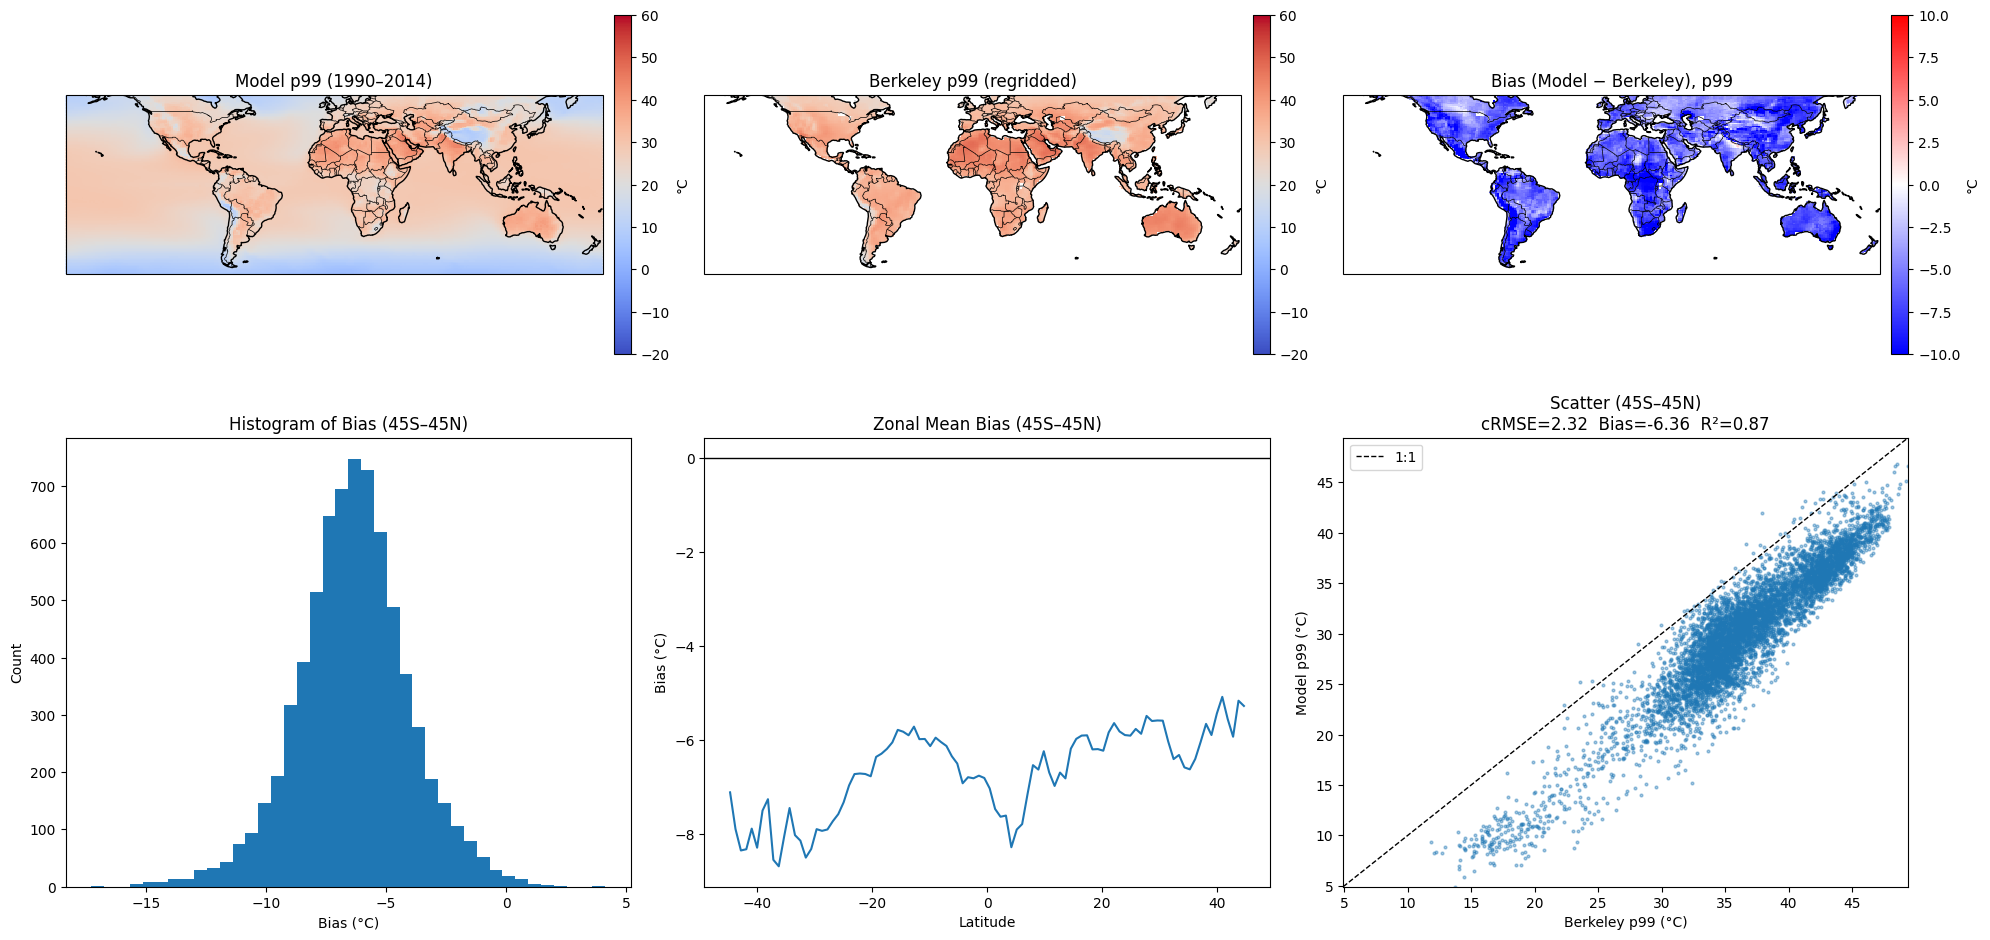

Saved diagnostics: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/TaiESM1_p99_diagnostics.png


In [ ]:
# ===========================
# TaiESM1 p99 diagnostics
# ===========================
import os, numpy as np, xarray as xr, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

# ---- Pick model and paths ----
MODEL_ID   = "TaiESM1"
MID_MIN, MID_MAX = -60, 60      # map extent
LAT_MIN, LAT_MAX = -45, 45      # metrics region
OUTDIR_FIG = OUTPUT_DIR if "OUTPUT_DIR" in globals() else "output_figures_cmip6_p99"
os.makedirs(OUTDIR_FIG, exist_ok=True)

# ---- Minimal fallbacks for helpers (use your existing ones if present) ----
def _normalize_latlon(obj):
    if "latitude" in obj.coords: obj = obj.rename({"latitude":"lat"})
    if "longitude" in obj.coords: obj = obj.rename({"longitude":"lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords: obj = obj.sortby("lon")
    return obj

def _to_latlon_2d(da):
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray):
        da = xr.DataArray(da)
    da = _normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra: da = da.mean(dim=extra, keep_attrs=True)
    if "lat" in da.dims and da.lat.size>1 and float(da.lat[0])>float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def _calc_spatial_r2(m, o):
    mv = m.values.ravel(); ov = o.values.ravel()
    mask = ~np.isnan(mv) & ~np.isnan(ov)
    if not np.any(mask): return np.nan
    mv = mv[mask]; ov = ov[mask]
    mm = mv - mv.mean(); oo = ov - ov.mean()
    denom = np.sqrt((mm**2).sum() * (oo**2).sum())
    if denom == 0: return np.nan
    r = (mm*oo).sum()/denom
    return float(r**2)

def _metrics_centered(m, o):
    """Centered RMSE (bias-removed), Bias, spatial R^2."""
    m = _to_latlon_2d(m); o = _to_latlon_2d(o)
    assert m.shape == o.shape
    diff = m - o
    bias = float(diff.mean().values)
    crmse = float(((diff - diff.mean())**2).mean().values**0.5)
    r2 = _calc_spatial_r2(m, o)
    return crmse, bias, r2

def _plot_map(ax, da, title, vmin=None, vmax=None, cmap="coolwarm"):
    im = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
                            vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([-180, 180, MID_MIN, MID_MAX], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    return im

# ---- Acquire model p99 and Berkeley p99 (reuse your loaders if available) ----
if "open_model_p99_from_zarr" in globals():
    model_p99 = open_model_p99_from_zarr(MODEL_ID)
else:
    # minimal inline loader via intake
    import intake
    PANGEOCAT = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    Q99 = 0.99
    col = intake.open_esm_datastore(PANGEOCAT)
    cat = col.search(source_id=MODEL_ID, experiment_id="historical", table_id="day", variable_id="tasmax")
    dsets = cat.to_dataset_dict(zarr_kwargs={"consolidated": True, "use_cftime": True},
                                storage_options={"token": "anon"})
    ds = list(dsets.values())[0]
    ds = _normalize_latlon(ds)
    tas = ds["tasmax"].sel(time=slice("1990-01-01","2014-12-31"))
    units = tas.attrs.get("units","").lower()
    if units in ["k","kelvin"] or (float(tas.max())>200 and float(tas.min())>150):
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"
    model_p99 = tas.quantile(q=Q99, dim="time", skipna=True, keep_attrs=True)

# Load Berkeley p99
if "berkeley_native_full" in globals():
    berkeley_native = berkeley_native_full
else:
    BERKELEY_P99_PATH = f"{OUTDIR}/tmax_99th_percentile.nc" if "OUTDIR" in globals() else "tmax_99th_percentile.nc"
    dsb = xr.open_dataset(BERKELEY_P99_PATH)
    var = "tmax_99th_percentile" if "tmax_99th_percentile" in dsb else list(dsb.data_vars)[0]
    berkeley_native = _normalize_latlon(dsb[var])

# ---- Prep midlats, regrid, and metrics region ----
model_mid    = _to_latlon_2d(model_p99).sel(lat=slice(MID_MIN, MID_MAX))
berkeley_mid = _to_latlon_2d(berkeley_native).sel(lat=slice(MID_MIN, MID_MAX))
berkeley_rg  = berkeley_mid.interp(lat=model_mid["lat"], lon=model_mid["lon"], method="linear")
bias_map     = model_mid - berkeley_rg

model_lims = model_mid.sel(lat=slice(LAT_MIN, LAT_MAX))
obs_lims   = berkeley_rg.sel(lat=slice(LAT_MIN, LAT_MAX))
crmse, bias, r2 = _metrics_centered(model_lims, obs_lims)
print(f"[TaiESM1 diagnostics] cRMSE={crmse:.3f}  Bias={bias:.3f}  R²={r2:.3f} (45S–45N)")

# ---- Figure: 2 rows x 3 cols (3 maps + 3 diagnostics) ----
fig = plt.figure(figsize=(20, 10))

# Maps
proj = ccrs.PlateCarree()
ax1 = plt.subplot(2,3,1, projection=proj)
ax2 = plt.subplot(2,3,2, projection=proj)
ax3 = plt.subplot(2,3,3, projection=proj)

im1 = _plot_map(ax1, model_mid,   "Model p99 (1990–2014)", vmin=-20, vmax=60)
im2 = _plot_map(ax2, berkeley_rg, "Berkeley p99 (regridded)", vmin=-20, vmax=60)
im3 = _plot_map(ax3, bias_map,    "Bias (Model − Berkeley), p99", vmin=-10, vmax=10, cmap="bwr")

for ax, im in zip([ax1,ax2,ax3],[im1,im2,im3]):
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("°C")

# Diagnostics: histogram, zonal mean, scatter (45S–45N)
ax4 = plt.subplot(2,3,4)
d = (model_lims - obs_lims).values.ravel()
d = d[~np.isnan(d)]
ax4.hist(d, bins=40)
ax4.set_title("Histogram of Bias (45S–45N)")
ax4.set_xlabel("Bias (°C)"); ax4.set_ylabel("Count")

ax5 = plt.subplot(2,3,5)
# Zonal mean bias on common grid:
zonal_bias = (model_lims - obs_lims).mean(dim="lon")
ax5.plot(zonal_bias["lat"], zonal_bias)
ax5.axhline(0, lw=1, color="k")
ax5.set_title("Zonal Mean Bias (45S–45N)")
ax5.set_xlabel("Latitude"); ax5.set_ylabel("Bias (°C)")

ax6 = plt.subplot(2,3,6)
mvals = model_lims.values.ravel()
ovals = obs_lims.values.ravel()
mask = ~np.isnan(mvals) & ~np.isnan(ovals)
mvals = mvals[mask]; ovals = ovals[mask]
ax6.scatter(ovals, mvals, s=4, alpha=0.4)
mn = np.nanmin([mvals.min(), ovals.min()])
mx = np.nanmax([mvals.max(), ovals.max()])
ax6.plot([mn, mx], [mn, mx], 'k--', lw=1, label="1:1")
ax6.set_xlim(mn, mx); ax6.set_ylim(mn, mx)
ax6.set_xlabel("Berkeley p99 (°C)"); ax6.set_ylabel("Model p99 (°C)")
ax6.set_title(f"Scatter (45S–45N)\ncRMSE={crmse:.2f}  Bias={bias:.2f}  R²={r2:.2f}")
ax6.legend(loc="upper left")

plt.tight_layout()
out_png = os.path.join(OUTDIR_FIG, f"{MODEL_ID}_p99_diagnostics.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print("Saved diagnostics:", out_png)


Saved hotspot counts CSV: /content/drive/MyDrive/climate_work/output_figures_absmax_per_year/gfdl_absmax_hotspot_counts_1990_2014.csv
    lat     lon  count   max_temp  first_year  last_year
1  27.5  68.125      7  53.183685        1990       2013
6  31.5  46.875      7  52.775085        1995       2014
8  31.5  71.875      3  52.176971        1991       2007
2  27.5  69.375      1  53.129120        1998       1998
0  25.5  69.375      1  52.141724        1997       1997


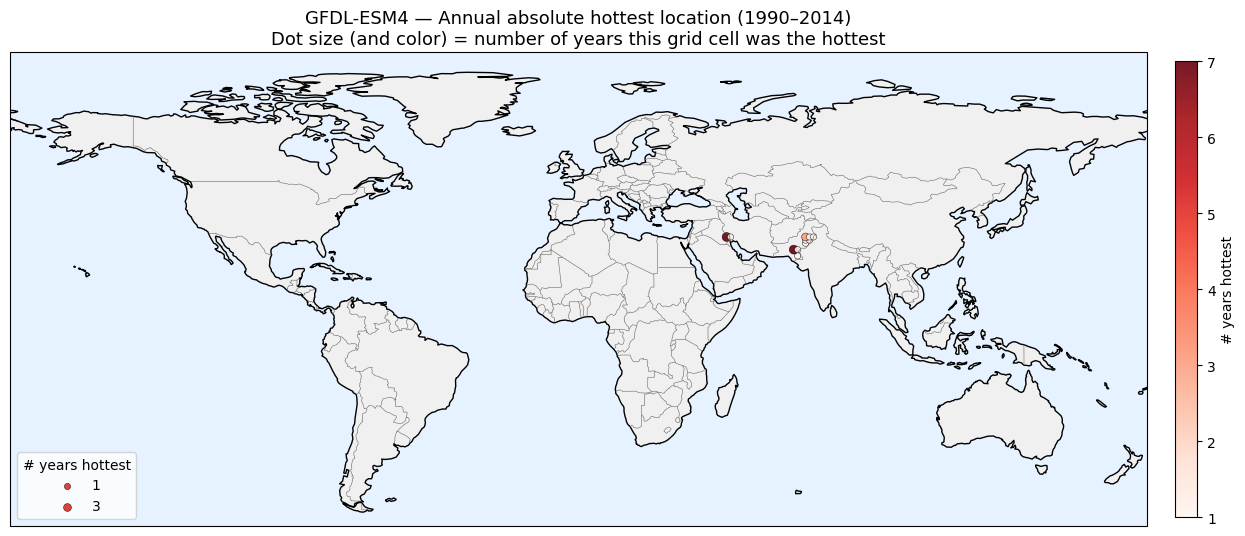

Saved figure: /content/drive/MyDrive/climate_work/output_figures_absmax_per_year/gfdl_absmax_hotspot_counts_1990_2014.png


In [ ]:
# ============================================================
# One-map hotspot view: size = how many years that cell was hottest
# Input: df with columns [year, lat, lon, tasmax_C]
# Output: single map + CSV of hotspot counts
# ============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# If df isn't in memory, load it:
# OUTDIR = "/content/drive/MyDrive/climate_work/output_figures_absmax_per_year"
# df     = pd.read_csv(f"{OUTDIR}/gfdl_absmax_per_year_1990_2014.csv")

OUTDIR  = "/content/drive/MyDrive/climate_work/output_figures_absmax_per_year"
os.makedirs(OUTDIR, exist_ok=True)
PNG_HS  = f"{OUTDIR}/gfdl_absmax_hotspot_counts_1990_2014.png"
CSV_HS  = f"{OUTDIR}/gfdl_absmax_hotspot_counts_1990_2014.csv"

LAT_MIN, LAT_MAX = -60, 90

# Optional: if you ever get nearly-identical coords, round them before grouping
# df["lat_r"] = df["lat"].round(5)
# df["lon_r"] = df["lon"].round(5)
# key_lat, key_lon = "lat_r", "lon_r"
key_lat, key_lon = "lat", "lon"

# Count how many years each location is the hottest
hotspots = (df.groupby([key_lat, key_lon], as_index=False)
              .agg(count=("year","size"),
                   max_temp=("tasmax_C","max"),
                   first_year=("year","min"),
                   last_year=("year","max")))

hotspots.to_csv(CSV_HS, index=False)
print("Saved hotspot counts CSV:", CSV_HS)
print(hotspots.sort_values("count", ascending=False).head())

# Size scaling: gentle nonlinearity so 1–10 years is visually distinct
def size_from_count(n):
    n = np.asarray(n, float)
    return 20 + 25*np.log10(np.maximum(n, 1.0))  # tweak constants to taste

# Color by count as well (optional); or use a single color
use_color_by_count = True
if use_color_by_count:
    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=hotspots["count"].min(), vmax=hotspots["count"].max())
    colors = cmap(norm(hotspots["count"].values))
else:
    colors = "#d73027"

fig = plt.figure(figsize=(14, 6))
proj = ccrs.PlateCarree()
ax = plt.subplot(1,1,1, projection=proj)

ax.set_global()
ax.set_extent([-180, 180, LAT_MIN, LAT_MAX], crs=proj)
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
ax.add_feature(cfeature.OCEAN, facecolor="#e6f2ff")
ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.4")

sc = ax.scatter(
    hotspots[key_lon].to_numpy(),
    hotspots[key_lat].to_numpy(),
    s=size_from_count(hotspots["count"].to_numpy()),
    c=(hotspots["count"].to_numpy() if use_color_by_count else colors),
    cmap=(cmap if use_color_by_count else None),
    norm=(norm if use_color_by_count else None),
    edgecolor="k", linewidth=0.35, alpha=0.9, transform=proj
)

# Legend for sizes (counts)
example_counts = np.unique(np.clip(hotspots["count"].to_numpy(), 1, None))
example_counts = np.array(sorted(set([1, 2, 3, 5, 10]) & set(example_counts) or [1, 2, 3, 5]))
handles = [plt.scatter([], [], s=size_from_count([c])[0], color="#d73027", alpha=0.9, edgecolor="k", linewidth=0.35)
           for c in example_counts]
ax.legend(handles, [str(int(c)) for c in example_counts],
          title="# years hottest", loc="lower left", frameon=True)

# Optional colorbar (if coloring by count)
if use_color_by_count:
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("# years hottest")

ax.set_title("GFDL-ESM4 — Annual absolute hottest location (1990–2014)\n"
             "Dot size (and color) = number of years this grid cell was the hottest", fontsize=13)

plt.tight_layout()
plt.savefig(PNG_HS, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure:", PNG_HS)


Opening Berkeley files...


/usr/local/lib/python3.12/dist-packages/dask/array/slicing.py:1029: PerformanceWarning: Increasing number of chunks by factor of 80
  p = blockwise(


Computing obs p99 (1980–2014)...
Computing obs hotspots (1980–2014)...
Loading future tasmax for BEST/WORST (2015–2100; ssp245)...

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:03&lt;00:00]</div>


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


...

Loading historical tasmax for BEST/WORST (1980–2014; historical)...

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:03&lt;00:00]</div>


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:02&lt;00:00]</div>

Computing model p99 (1980–2014; historical)...
Computing model hotspots (2015–2100 hottest-of-hot)...


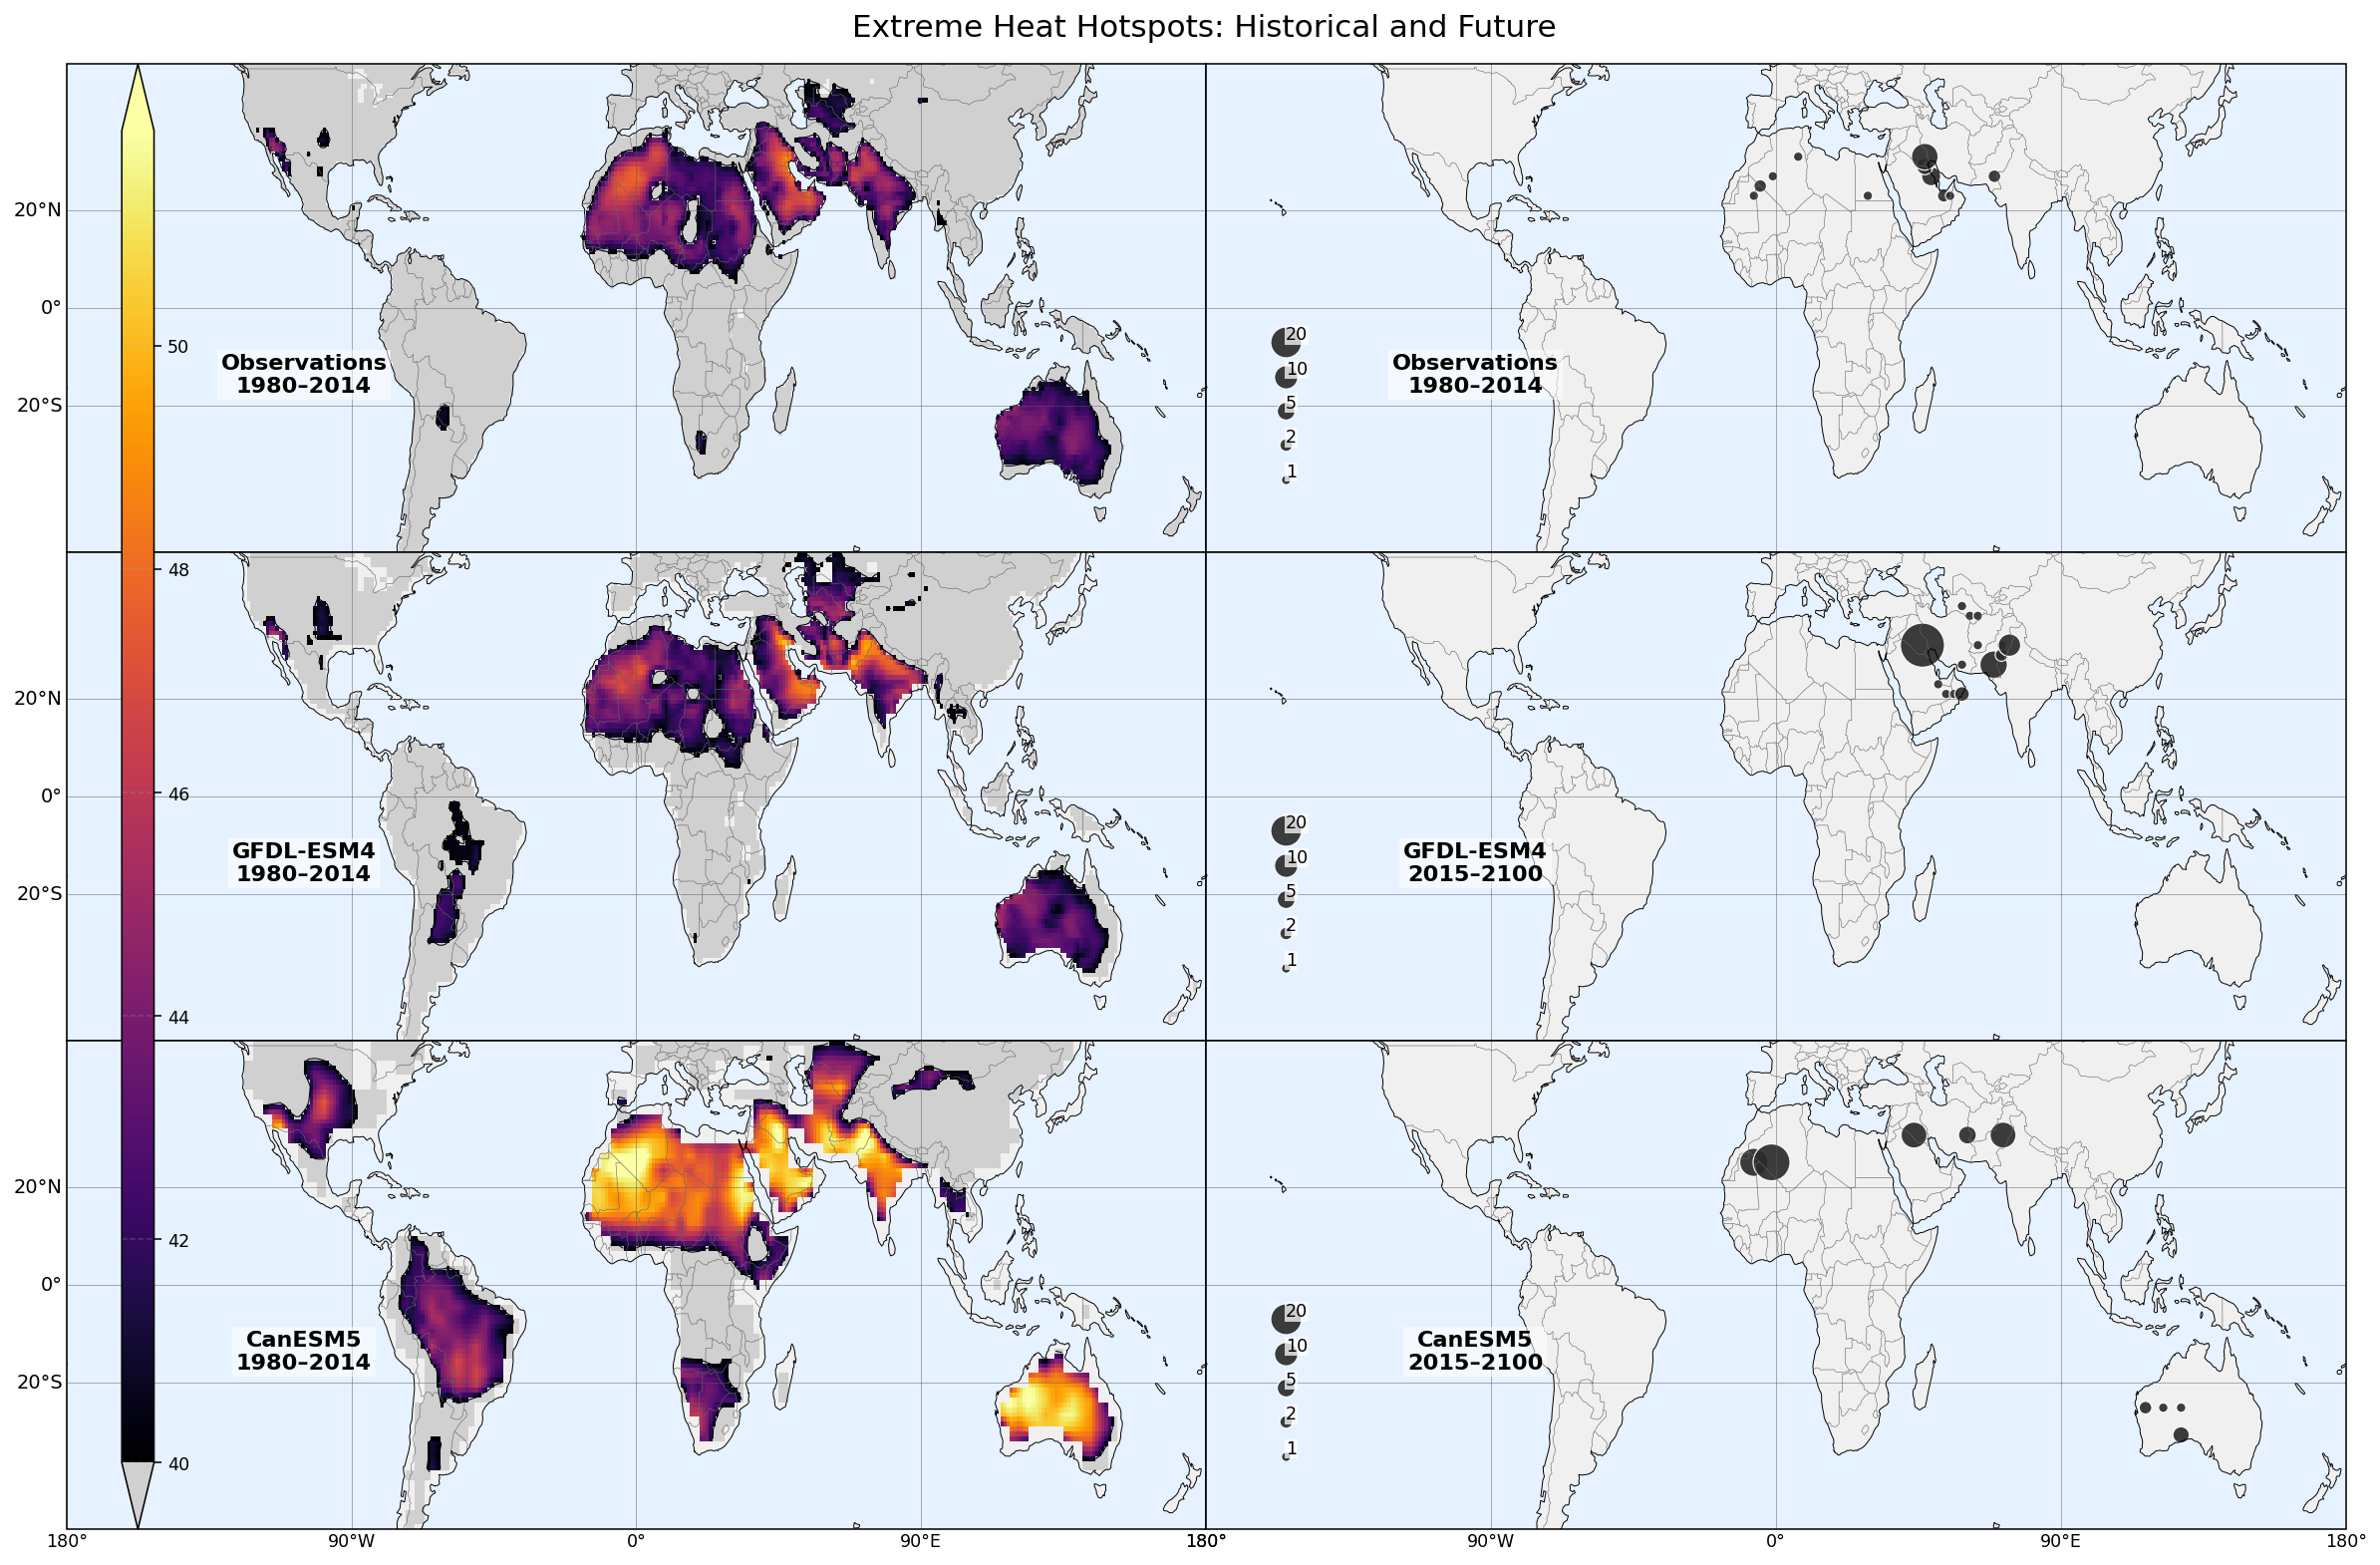

Saved: /content/drive/MyDrive/climate_work/output_figures_absmax_per_year/three_by_two_gapless_shorttitle_yearsCentered_labelsAllPanels_noOverlap_ssp245.png

NOTE (for your caption):
Future hotspots use ssp245 (2015–2100) member r1i1p1f1.
Left-column p99 maps for models use historical (1980–2014) to match the obs window.


In [4]:
# === 3×2 (Obs | BEST_MODEL | WORST_MODEL; left=p99, right=hotspots) ===
# Layout + styling:
# • Gapless layout, Cartopy PlateCarree
# • LEFT column: p99 maps (inferno) 1980–2014 for ALL three rows (Obs, Best, Worst)
# • RIGHT column: "hottest-of-hot" hotspot frequencies
#   - Obs: 1980–2014
#   - Best/Worst: 2015–2100 (SSP2-4.5)
#   - For each year: land grid cell of global maximum tasmax
#   - Count # years each grid cell is the global max (marker size ∝ count)
# • VERTICAL colorbar placed far left; ticks on RIGHT; no colorbar label
# • Two-line in-panel labels on ALL panels: Name + Years
# • Adjusted label/legend positions to avoid overlaps:
#   - Left-column labels nudged right (east) away from colorbar
#   - Right-column dot-size legends shifted left (west)
#   - Right-column labels nudged right (east)
#
# NOTE: This version makes the left-column model p99 fields consistent with 1980–2014
# by using the CMIP6 historical experiment for BEST/WORST p99. Hotspots for BEST/WORST
# use SSP2-4.5 (ssp245) over 2015–2100.

import os, shutil
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import intake

# If dask is present, threads scheduler is often more stable in Colab
try:
    import dask
    dask.config.set(scheduler="threads")
except Exception:
    pass

# ----------------- SETTINGS -----------------
WORKDIR = "/content/drive/MyDrive/climate_work"
BERKELEY_FILES = [
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_1980.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_1990.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_2000.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_2010.nc",
]

# HIST window (obs + model p99)
HIST0, HIST1 = "1980-01-01", "2014-12-31"

# FUTURE window (models + hotspots definition)
FUT0, FUT1 = "2015-01-01", "2100-12-31"

SCENARIO  = "ssp245"       # used only for loading future SSP; omit from title/caption if desired
MEMBER_ID = "r1i1p1f1"

LAT_MIN, LAT_MAX = -50, 50
THRESH_C = 40.0  # contour only

BEST_MODEL  = "GFDL-ESM4"
WORST_MODEL = "CanESM5"

# Chunking (safer for Colab)
TIME_CHUNK_DAYS = 365
LAT_CHUNK = 180
LON_CHUNK = 180

# Hotspot performance (coarsen ONLY during hotspot finding; 1 disables)
HOTSPOT_COARSEN = 2

# ---- Label positions (separate for left vs right columns) ----
# Left column (p99): shift labels right (east) so they don't overlap the colorbar
LABEL_LON_LEFT  = -105
LABEL_LAT_LEFT  = -18

# Right column (hotspots): shift labels right (east) so they don't overlap size legend
LABEL_LON_RIGHT = -95
LABEL_LAT_RIGHT = -18

# ---- Dot-size legend position (move circles left / west in hotspot panels) ----
SIZELEG_LON_RIGHT = -155
SIZELEG_LAT_START = -35

FIGSIZE = (16.5, 12.0)
OUTDIR = f"{WORKDIR}/output_figures_absmax_per_year"
os.makedirs(OUTDIR, exist_ok=True)
OUTPNG = f"{OUTDIR}/three_by_two_gapless_shorttitle_yearsCentered_labelsAllPanels_noOverlap_{SCENARIO}.png"

CMAP_P99 = "inferno"

# Hotspot dots
DOT_COLOR = "#2b2b2b"; DOT_EDGE="white"; DOT_EW=0.65; DOT_ALPHA=0.92
S_MIN, S_MAX = 24, 520; GAMMA = 0.85

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# ----------------- HELPERS -----------------
def normalize_coords(ds):
    if "latitude"  in ds.coords: ds = ds.rename({"latitude": "lat"})
    if "longitude" in ds.coords: ds = ds.rename({"longitude":"lon"})
    if "lon" in ds.coords:
        lon = xr.where(ds["lon"] > 180, ds["lon"] - 360, ds["lon"])
        ds  = ds.assign_coords(lon=lon).sortby("lon")
    if "lat" in ds.coords and ds.lat.size > 1 and float(ds.lat[0]) > float(ds.lat[-1]):
        ds = ds.sortby("lat")
    return ds

def open_one_localcopy(path):
    p = f"/content/{os.path.basename(path)}"
    if not os.path.exists(p) or os.path.getsize(p) != os.path.getsize(path):
        shutil.copy2(path, p)
    last = None
    for eng in ["h5netcdf","netcdf4","scipy"]:
        try:
            kw = dict(chunks={"time":90, "lat":LAT_CHUNK, "lon":LON_CHUNK})
            if eng=="h5netcdf":
                return xr.open_dataset(p, engine=eng, backend_kwargs={"invalid_netcdf":True}, **kw)
            elif eng=="netcdf4":
                return xr.open_dataset(p, engine=eng, **kw)
            else:
                return xr.open_dataset(p, engine=eng)
        except Exception as e:
            last = e
    raise last

def ensure_datetime_time(ds, t0):
    if "time" in ds.dims and "time" in ds.coords:
        return ds
    n = ds.sizes["time"]
    t = pd.date_range(t0, periods=n, freq="D")
    return ds.assign_coords(time=("time", t))

def maybe_coarsen_latlon(da, factor):
    if factor is None or int(factor) <= 1:
        return da
    f = int(factor)
    return da.coarsen(lat=f, lon=f, boundary="trim").mean()

def shared_size_map(counts, cmin, cmax, smin=S_MIN, smax=S_MAX, gamma=GAMMA):
    counts = np.asarray(counts, float)
    if cmax <= cmin:
        return np.full_like(counts, (smin+smax)/2)
    x = (counts - cmin) / (cmax - cmin)
    x = np.clip(x, 0, 1) ** gamma
    return smin + x * (smax - smin)

def plot_base(ax):
    ax.set_extent([-180, 180, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    ax.set_facecolor("#e6f2ff")
    ax.add_feature(cfeature.LAND,  facecolor="#f0f0f0")
    ax.add_feature(cfeature.OCEAN, facecolor="#e6f2ff")
    ax.coastlines(resolution="110m", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.4")
    for s in ["left","right","bottom","top"]:
        ax.spines[s].set_linewidth(0.55)

def to_latlon2d(da):
    if "quantile" in da.dims:
        da = da.isel(quantile=0)
    for d in list(da.dims):
        if d not in ("lat","lon"):
            da = da.isel({d:0}) if da.sizes[d]==1 else da.mean(d)
    rn = {}
    if "latitude"  in da.dims: rn["latitude"]  = "lat"
    if "longitude" in da.dims: rn["longitude"] = "lon"
    if rn: da = da.rename(rn)
    return da.transpose("lat","lon")

def plot_p99_field(ax, p99_da, vmin=THRESH_C, vmax=None, cmap=CMAP_P99):
    plot_base(ax)
    p99_2d = to_latlon2d(p99_da).sel(lat=slice(LAT_MIN, LAT_MAX))
    if vmax is None:
        vmax = float(np.nanpercentile(p99_2d, 99))
        vmax = max(vmax, THRESH_C + 5)
    cmap_obj = mpl.colormaps.get_cmap(cmap).copy()
    cmap_obj.set_under("#d0d0d0")
    im = ax.pcolormesh(p99_2d["lon"], p99_2d["lat"], p99_2d,
                       transform=ccrs.PlateCarree(), cmap=cmap_obj,
                       vmin=vmin, vmax=vmax, shading="nearest")
    ax.contour(p99_2d["lon"], p99_2d["lat"], p99_2d, levels=[THRESH_C],
               colors="k", linewidths=0.55, transform=ccrs.PlateCarree())
    return im

def plot_hotspots_sizeonly(ax, hs_df, cmin, cmax):
    plot_base(ax)
    if hs_df is not None and len(hs_df):
        counts = hs_df["count"].to_numpy().astype(float)
        sizes  = shared_size_map(counts, cmin, cmax)
        ax.scatter(hs_df["lon"].to_numpy(), hs_df["lat"].to_numpy(),
                   s=sizes, c=DOT_COLOR, alpha=DOT_ALPHA,
                   edgecolor=DOT_EDGE, linewidth=DOT_EW,
                   transform=ccrs.PlateCarree())
    else:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="0.4")

def interp_mask_to(landmask_ref, lat, lon, method="nearest"):
    lm = landmask_ref
    if "latitude"  in lm.coords: lm = lm.rename({"latitude":"lat"})
    if "longitude" in lm.coords: lm = lm.rename({"longitude":"lon"})
    if float(lm.lon.max()) > 180:
        lm = lm.assign_coords(lon=xr.where(lm.lon > 180, lm.lon - 360, lm.lon)).sortby("lon")
    return lm.interp(lat=lat, lon=lon, method=method)

# Two-line label: Name + Years (centered), with per-axis lon/lat
def add_inpanel_label_ocean_two_lines(ax, name, years, lon, lat):
    ax.text(
        lon, lat, f"{name}\n{years}",
        transform=ccrs.PlateCarree(),
        ha="center", va="bottom",
        fontsize=11.5, fontweight="bold",
        linespacing=1.15,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=2.0),
        zorder=5
    )

def add_size_legend_vertical(ax, cmin, cmax, lon, lat_start, dlat=7, max_marks=5):
    if cmax < cmin: cmin, cmax = cmax, cmin
    candidates = np.array([1, 2, 3, 5, 8, 10, 15, 20])
    ticks = [int(t) for t in candidates if cmin <= t <= cmax] or [int(cmin), int(cmax)]
    ticks = sorted(set(ticks))
    if len(ticks) > max_marks:
        idx = np.linspace(0, len(ticks)-1, num=max_marks, dtype=int)
        ticks = [ticks[i] for i in idx]
    for i, c in enumerate(ticks):
        s = shared_size_map([c], cmin, cmax)[0]
        y = lat_start + i*dlat
        ax.scatter(lon, y, s=s, c=DOT_COLOR, alpha=DOT_ALPHA,
                   edgecolor=DOT_EDGE, linewidth=DOT_EW,
                   transform=ccrs.PlateCarree(), zorder=3)
        ax.text(lon, y + 1.5, f"{c}", ha="left", va="center",
                transform=ccrs.PlateCarree(), fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.4),
                zorder=4)

def add_geo_labels(ax, show_left=False, show_bottom=False):
    meridians = [-180, -90, 0, 90, 180]; parallels = [-20, 0, 20]
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      xlocs=meridians, ylocs=parallels,
                      linewidth=0.4, color="0.35", alpha=0.6, linestyle="-", zorder=6)
    gl.rotate_labels = False
    gl.xformatter = LongitudeFormatter(number_format=".0f", degree_symbol="°")
    gl.yformatter = LatitudeFormatter(number_format=".0f", degree_symbol="°")
    gl.top_labels = False; gl.right_labels = False
    gl.left_labels = bool(show_left); gl.bottom_labels = bool(show_bottom)
    gl.xlabel_style = dict(size=9, weight="normal"); gl.ylabel_style = dict(size=10, weight="normal")
    gl.xpadding = 2; gl.ypadding = 2

# ---- HOTTEST-OF-HOT: annual global max locations -> counts ----
def yearmax_locations_df(da_time_lat_lon, coarsen_factor=1):
    da = da_time_lat_lon.sel(lat=slice(LAT_MIN, LAT_MAX))
    da = maybe_coarsen_latlon(da, coarsen_factor)

    annmax = da.groupby("time.year").max("time")  # (year, lat, lon)
    annmax = annmax.chunk({"year": 1, "lat": LAT_CHUNK, "lon": LON_CHUNK})

    stacked = annmax.stack(space=("lat","lon"))
    imax = stacked.argmax("space").compute()
    vmax = stacked.max("space").compute()

    years = imax["year"].values.astype(int)
    nlat, nlon = int(annmax.sizes["lat"]), int(annmax.sizes["lon"])
    flat = np.asarray(imax.values).astype(int).ravel()
    ilat, ilon = np.unravel_index(flat, (nlat, nlon))

    latv = annmax["lat"].values.astype(float)
    lonv = annmax["lon"].values.astype(float)

    lats = latv[ilat].astype(float).ravel()
    lons = lonv[ilon].astype(float).ravel()
    vals = np.asarray(vmax.values).astype(float).ravel()

    return pd.DataFrame({"year": years, "lat": lats, "lon": lons, "value": vals}).sort_values("year")

def hotspot_counts_df(df_yearmax):
    hs = (df_yearmax.groupby(["lat","lon"], as_index=False)
            .agg(count=("year","size"),
                 max_value=("value","max"),
                 first_year=("year","min"),
                 last_year=("year","max")))
    hs["count"] = hs["count"].astype(int)
    return hs

# ----------------- DATA PREP (OBS: HIST) -----------------
print("Opening Berkeley files...")
opened = [normalize_coords(open_one_localcopy(f)) for f in BERKELEY_FILES]
dsb = xr.concat(opened, dim="time", data_vars="minimal", coords="minimal", compat="override")

try:
    from xarray.coders import CFDatetimeCoder
except Exception:
    try:
        from xarray.coding.times import CFDatetimeCoder
    except Exception:
        CFDatetimeCoder = None

if CFDatetimeCoder is not None:
    time_coder = CFDatetimeCoder(use_cftime=True)
    dsb = xr.decode_cf(dsb, decode_times=time_coder, mask_and_scale=True).sortby("time")
else:
    dsb = xr.decode_cf(dsb, use_cftime=True, mask_and_scale=True).sortby("time")

dsb = ensure_datetime_time(dsb, HIST0).sel(time=slice(HIST0, HIST1))

anom = dsb["temperature"]
clim = dsb["climatology"]
doy  = dsb["day_of_year"]

lmask_ref = dsb.get("land_mask")
if lmask_ref is None:
    lmask_ref = xr.where(~xr.ufuncs.isnan(clim.isel(time=0) if "time" in clim.dims else clim.isel(dayofyear=0)),
                         1.0, 0.0)

if "day_number" in clim.dims: clim = clim.rename({"day_number":"dayofyear"})
elif "day_of_year" in clim.dims: clim = clim.rename({"day_of_year":"dayofyear"})
elif "time" in clim.dims and clim.sizes["time"] in (365, 366): clim = clim.rename({"time":"dayofyear"})

doy_i   = xr.where(doy > 365, 365, doy).astype("int32")
start   = int(np.nanmin(clim["dayofyear"].values))
indexer = xr.where(doy_i > 365, 364, doy_i - 1) if start == 0 else doy_i
clim_sel = clim.sel(dayofyear=indexer)

Tmax_abs_hist = (anom + clim_sel).rename("Tmax_abs").where(lmask_ref > 0.5)
Tmax_abs_hist = Tmax_abs_hist.chunk({"time": TIME_CHUNK_DAYS, "lat": LAT_CHUNK, "lon": LON_CHUNK})

print("Computing obs p99 (1980–2014)...")
p99_obs = Tmax_abs_hist.quantile(0.99, dim="time")

print("Computing obs hotspots (1980–2014)...")
df_obs_yearmax = yearmax_locations_df(Tmax_abs_hist, coarsen_factor=HOTSPOT_COARSEN)
hs_obs = hotspot_counts_df(df_obs_yearmax)

# ----------------- MODELS -----------------
def load_model_tasmax(source_id, experiment_id, t0, t1, member_id=MEMBER_ID):
    col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
    cat = col.search(
        source_id=source_id,
        experiment_id=experiment_id,
        table_id="day",
        variable_id="tasmax",
        member_id=member_id,
    )
    dsets = cat.to_dataset_dict(
        zarr_kwargs={"consolidated": True, "use_cftime": True},
        storage_options={"token": "anon"}
    )
    if not dsets:
        raise ValueError(f"No dataset found for {source_id} {experiment_id} day tasmax {member_id}")

    ds = normalize_coords(list(dsets.values())[0])
    tas = ds["tasmax"].sel(time=slice(t0, t1))
    tas = tas.chunk({"time": TIME_CHUNK_DAYS, "lat": LAT_CHUNK, "lon": LON_CHUNK})

    u = str(tas.attrs.get("units","")).lower()
    if u in ["k","kelvin"] or float(tas.isel(time=0).max()) > 200:
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"
    return tas

# ---- FUTURE tasmax (for hotspots only) ----
print(f"Loading future tasmax for BEST/WORST (2015–2100; {SCENARIO})...")
tas_best_fut  = load_model_tasmax(BEST_MODEL,  SCENARIO, FUT0, FUT1)
tas_worst_fut = load_model_tasmax(WORST_MODEL, SCENARIO, FUT0, FUT1)

mask_best_fut  = interp_mask_to(lmask_ref, lat=tas_best_fut.lat,  lon=tas_best_fut.lon,  method="nearest")
mask_worst_fut = interp_mask_to(lmask_ref, lat=tas_worst_fut.lat, lon=tas_worst_fut.lon, method="nearest")
tas_best_land_fut  = tas_best_fut.where(mask_best_fut  > 0.5)
tas_worst_land_fut = tas_worst_fut.where(mask_worst_fut > 0.5)

# ---- HISTORICAL tasmax (for p99 maps; to match 1980–2014 on LEFT column) ----
print("Loading historical tasmax for BEST/WORST (1980–2014; historical)...")
tas_best_hist  = load_model_tasmax(BEST_MODEL,  "historical", HIST0, HIST1)
tas_worst_hist = load_model_tasmax(WORST_MODEL, "historical", HIST0, HIST1)

mask_best_hist  = interp_mask_to(lmask_ref, lat=tas_best_hist.lat,  lon=tas_best_hist.lon,  method="nearest")
mask_worst_hist = interp_mask_to(lmask_ref, lat=tas_worst_hist.lat, lon=tas_worst_hist.lon, method="nearest")
tas_best_land_hist  = tas_best_hist.where(mask_best_hist  > 0.5)
tas_worst_land_hist = tas_worst_hist.where(mask_worst_hist > 0.5)

def regrid_to_berkeley_bilinear(p99_native_2d, target_lat, target_lon):
    da = to_latlon2d(p99_native_2d)
    if float(da.lon.max()) > 180:
        da = da.assign_coords(lon=xr.where(da.lon > 180, da.lon - 360, da.lon)).sortby("lon")
    return da.interp(lat=target_lat, lon=target_lon, method="linear")

print("Computing model p99 (1980–2014; historical)...")
p99_best_native  = tas_best_land_hist.quantile(0.99, dim="time")
p99_worst_native = tas_worst_land_hist.quantile(0.99, dim="time")
p99_best  = regrid_to_berkeley_bilinear(p99_best_native,  dsb.lat, dsb.lon)
p99_worst = regrid_to_berkeley_bilinear(p99_worst_native, dsb.lat, dsb.lon)

print("Computing model hotspots (2015–2100 hottest-of-hot)...")
df_best_yearmax = yearmax_locations_df(tas_best_land_fut,  coarsen_factor=HOTSPOT_COARSEN)
df_wrst_yearmax = yearmax_locations_df(tas_worst_land_fut, coarsen_factor=HOTSPOT_COARSEN)
hs_best = hotspot_counts_df(df_best_yearmax)
hs_wrst = hotspot_counts_df(df_wrst_yearmax)

# ----------------- PLOTTING -----------------
fig = plt.figure(figsize=FIGSIZE)
fig.suptitle("Extreme Heat Hotspots: Historical and Future", fontsize=16, y=0.985)

proj = ccrs.PlateCarree()

def make_axes_grid(fig, nrows=3, ncols=2,
                   left=0.006, right=0.996, top=0.955, bottom=0.080,
                   row_gap=0.0, col_gap=0.0001):
    width, height = right-left, top-bottom
    cell_w = (width - (ncols-1)*col_gap) / ncols
    cell_h = (height - (nrows-1)*row_gap) / nrows
    axes = []
    for r in range(nrows):
        row = []
        y0 = top - (r+1)*cell_h - r*row_gap
        for c in range(ncols):
            x0 = left + c*(cell_w + col_gap)
            ax = fig.add_axes([x0, y0, cell_w, cell_h], projection=proj)
            row.append(ax)
        axes.append(row)
    return axes, dict(cell_w=cell_w, cell_h=cell_h, left=left, right=right,
                      top=top, bottom=bottom, width=width, height=height)

(axes, layout) = make_axes_grid(fig, 3, 2, left=0.006, right=0.996,
                                top=0.955, bottom=0.080,
                                row_gap=0.0, col_gap=0.0001)

ax_obs_p99,  ax_obs_hot  = axes[0]
ax_best_p99, ax_best_hot = axes[1]
ax_wrst_p99, ax_wrst_hot = axes[2]

def robust_p99_vmax(da):
    d2 = to_latlon2d(da).sel(lat=slice(LAT_MIN, LAT_MAX))
    vmax = float(np.nanpercentile(d2, 99))
    return max(vmax, THRESH_C + 5)

vmax_all = max(
    robust_p99_vmax(p99_obs),
    robust_p99_vmax(p99_best),
    robust_p99_vmax(p99_worst),
)

im_obs  = plot_p99_field(ax_obs_p99,  p99_obs,   vmin=THRESH_C, vmax=vmax_all, cmap=CMAP_P99)
im_best = plot_p99_field(ax_best_p99, p99_best,  vmin=THRESH_C, vmax=vmax_all, cmap=CMAP_P99)
im_wrst = plot_p99_field(ax_wrst_p99, p99_worst, vmin=THRESH_C, vmax=vmax_all, cmap=CMAP_P99)

all_counts = []
for hs in (hs_obs, hs_best, hs_wrst):
    if hs is not None and len(hs):
        all_counts.extend(hs["count"].to_numpy().tolist())
cmin = max(1, int(np.min(all_counts))) if all_counts else 1
cmax = int(np.max(all_counts)) if all_counts else 1

plot_hotspots_sizeonly(ax_obs_hot,  hs_obs,  cmin, cmax)
plot_hotspots_sizeonly(ax_best_hot, hs_best, cmin, cmax)
plot_hotspots_sizeonly(ax_wrst_hot, hs_wrst, cmin, cmax)

# ----------------- LABELS ON ALL PANELS -----------------
# LEFT column: ALL 1980–2014 (shifted right away from colorbar)
add_inpanel_label_ocean_two_lines(ax_obs_p99,  "Observations", "1980–2014",
                                  lon=LABEL_LON_LEFT, lat=LABEL_LAT_LEFT)
add_inpanel_label_ocean_two_lines(ax_best_p99, BEST_MODEL,    "1980–2014",
                                  lon=LABEL_LON_LEFT, lat=LABEL_LAT_LEFT)
add_inpanel_label_ocean_two_lines(ax_wrst_p99, WORST_MODEL,   "1980–2014",
                                  lon=LABEL_LON_LEFT, lat=LABEL_LAT_LEFT)

# RIGHT column: top is obs 1980–2014; bottom two are 2015–2100 (labels nudged right)
add_inpanel_label_ocean_two_lines(ax_obs_hot,  "Observations", "1980–2014",
                                  lon=LABEL_LON_RIGHT, lat=LABEL_LAT_RIGHT)
add_inpanel_label_ocean_two_lines(ax_best_hot, BEST_MODEL,    "2015–2100",
                                  lon=LABEL_LON_RIGHT, lat=LABEL_LAT_RIGHT)
add_inpanel_label_ocean_two_lines(ax_wrst_hot, WORST_MODEL,   "2015–2100",
                                  lon=LABEL_LON_RIGHT, lat=LABEL_LAT_RIGHT)

# Dot-size legends (moved left in hotspot panels)
if len(hs_obs):
    add_size_legend_vertical(ax_obs_hot,  cmin, cmax,
                             lon=SIZELEG_LON_RIGHT, lat_start=SIZELEG_LAT_START)
if len(hs_best):
    add_size_legend_vertical(ax_best_hot, cmin, cmax,
                             lon=SIZELEG_LON_RIGHT, lat_start=SIZELEG_LAT_START)
if len(hs_wrst):
    add_size_legend_vertical(ax_wrst_hot, cmin, cmax,
                             lon=SIZELEG_LON_RIGHT, lat_start=SIZELEG_LAT_START)

# Geo labels
add_geo_labels(ax_obs_p99,  show_left=True,  show_bottom=False)
add_geo_labels(ax_best_p99, show_left=True,  show_bottom=False)
add_geo_labels(ax_wrst_p99, show_left=True,  show_bottom=True)

add_geo_labels(ax_obs_hot,  show_left=False, show_bottom=False)
add_geo_labels(ax_best_hot, show_left=False, show_bottom=False)
add_geo_labels(ax_wrst_hot, show_left=False, show_bottom=True)

# ---- VERTICAL colorbar on the far left ----
CBAR_WIDTH  = 0.014
CBAR_PAD_X  = 0.060
CBAR_MIN_X  = 0.03
cbar_x = max(CBAR_MIN_X, layout["left"] - CBAR_PAD_X - CBAR_WIDTH)
cbar_y = layout["bottom"]; cbar_h = layout["height"]
cax_left_vert = fig.add_axes([cbar_x, cbar_y, CBAR_WIDTH, cbar_h])
cbar = fig.colorbar(im_obs, cax=cax_left_vert, orientation="vertical", extend="both")
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.tick_params(labelright=True, right=True, labelleft=False, left=False, labelsize=9)
cbar.set_label("")

plt.savefig(OUTPNG, bbox_inches="tight", pad_inches=0.1)
plt.show()
print("Saved:", OUTPNG)

print("\nNOTE (for your caption):")
print(f"Future hotspots use {SCENARIO} ({FUT0[:4]}–{FUT1[:4]}) member {MEMBER_ID}.")
print("Left-column p99 maps for models use historical (1980–2014) to match the obs window.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Opening Berkeley files...


/usr/local/lib/python3.12/dist-packages/dask/array/slicing.py:1029: PerformanceWarning: Increasing number of chunks by factor of 80
  p = blockwise(


Computing OBS hotspots (1980–2014)...
Computing model hotspots for historical + future...

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:02&lt;00:00]</div>

  ACCESS-CM2     historical  years= 35  cachedOK

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


...

<div><progress max="1" value="1"></progress> 100.00% [1/1 00:05&lt;00:00]</div>

  NorESM2-MM     historical  years= 35  cachedOK

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:07&lt;00:00]</div>

  NorESM2-MM     ssp245      years= 86  cachedOK


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


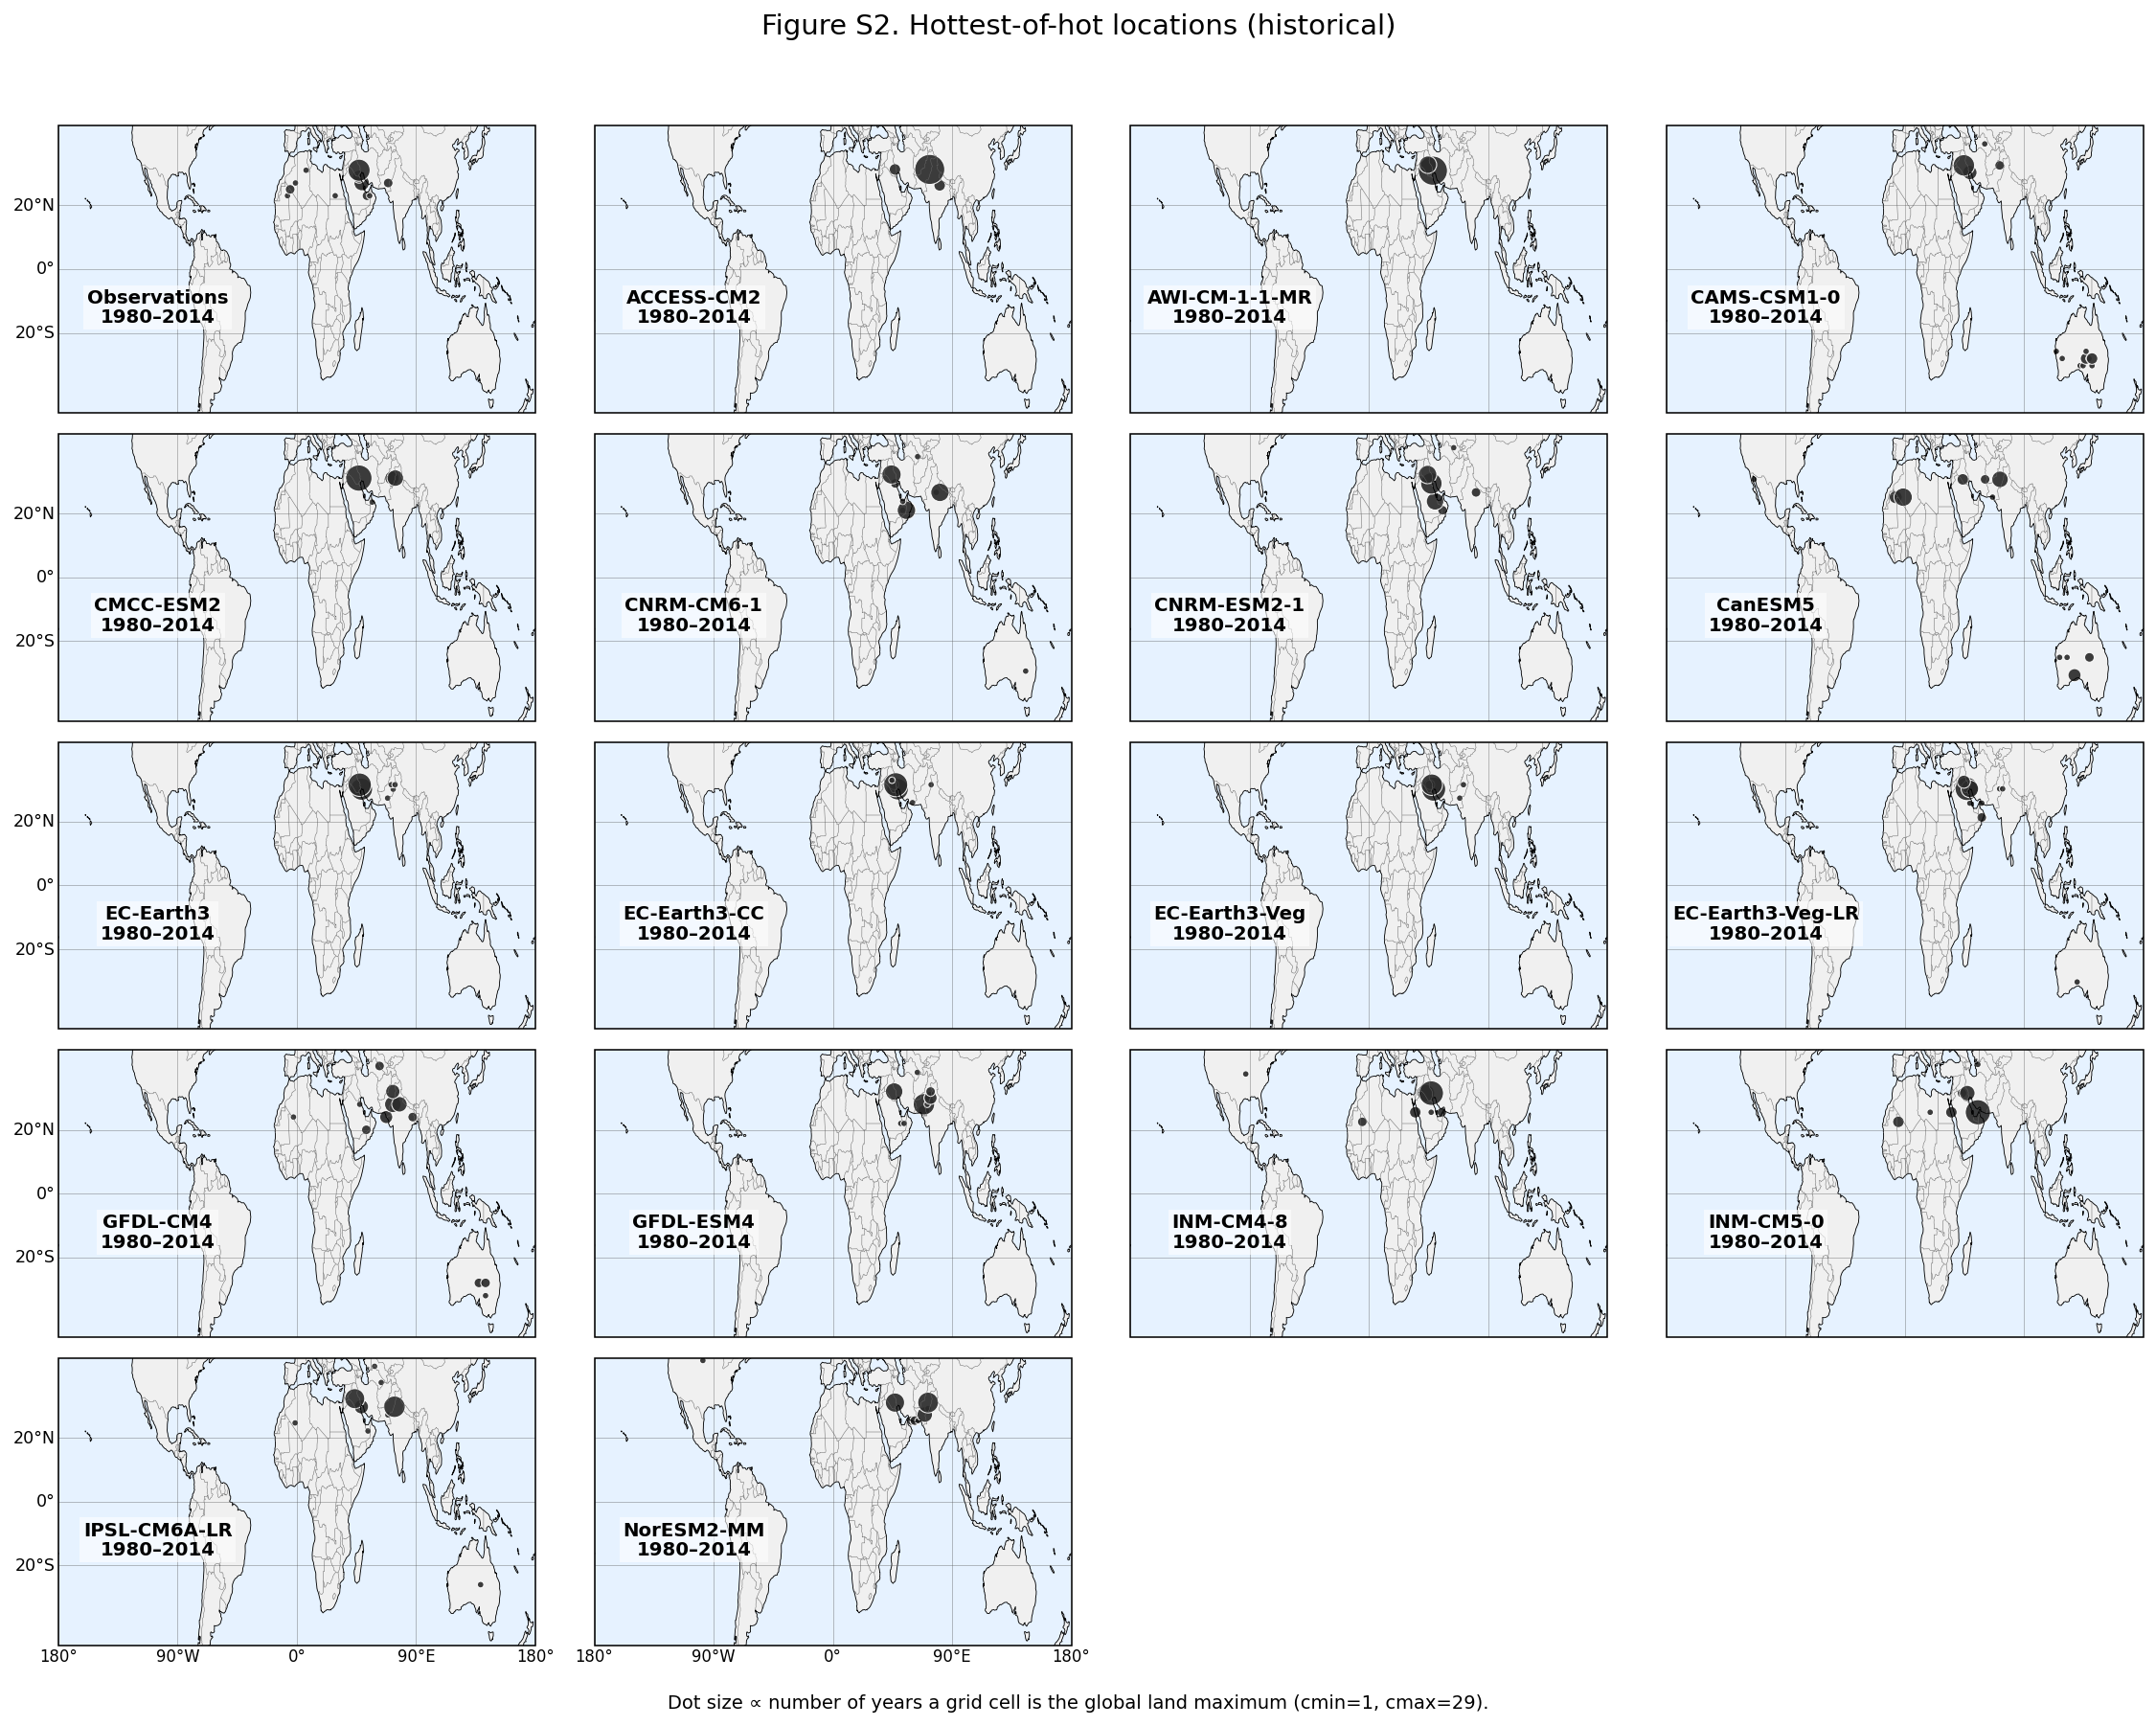

Saved: /content/drive/MyDrive/climate_work/output_supp_hotspots/FigS2_hotspots_historical_1980-2014.png


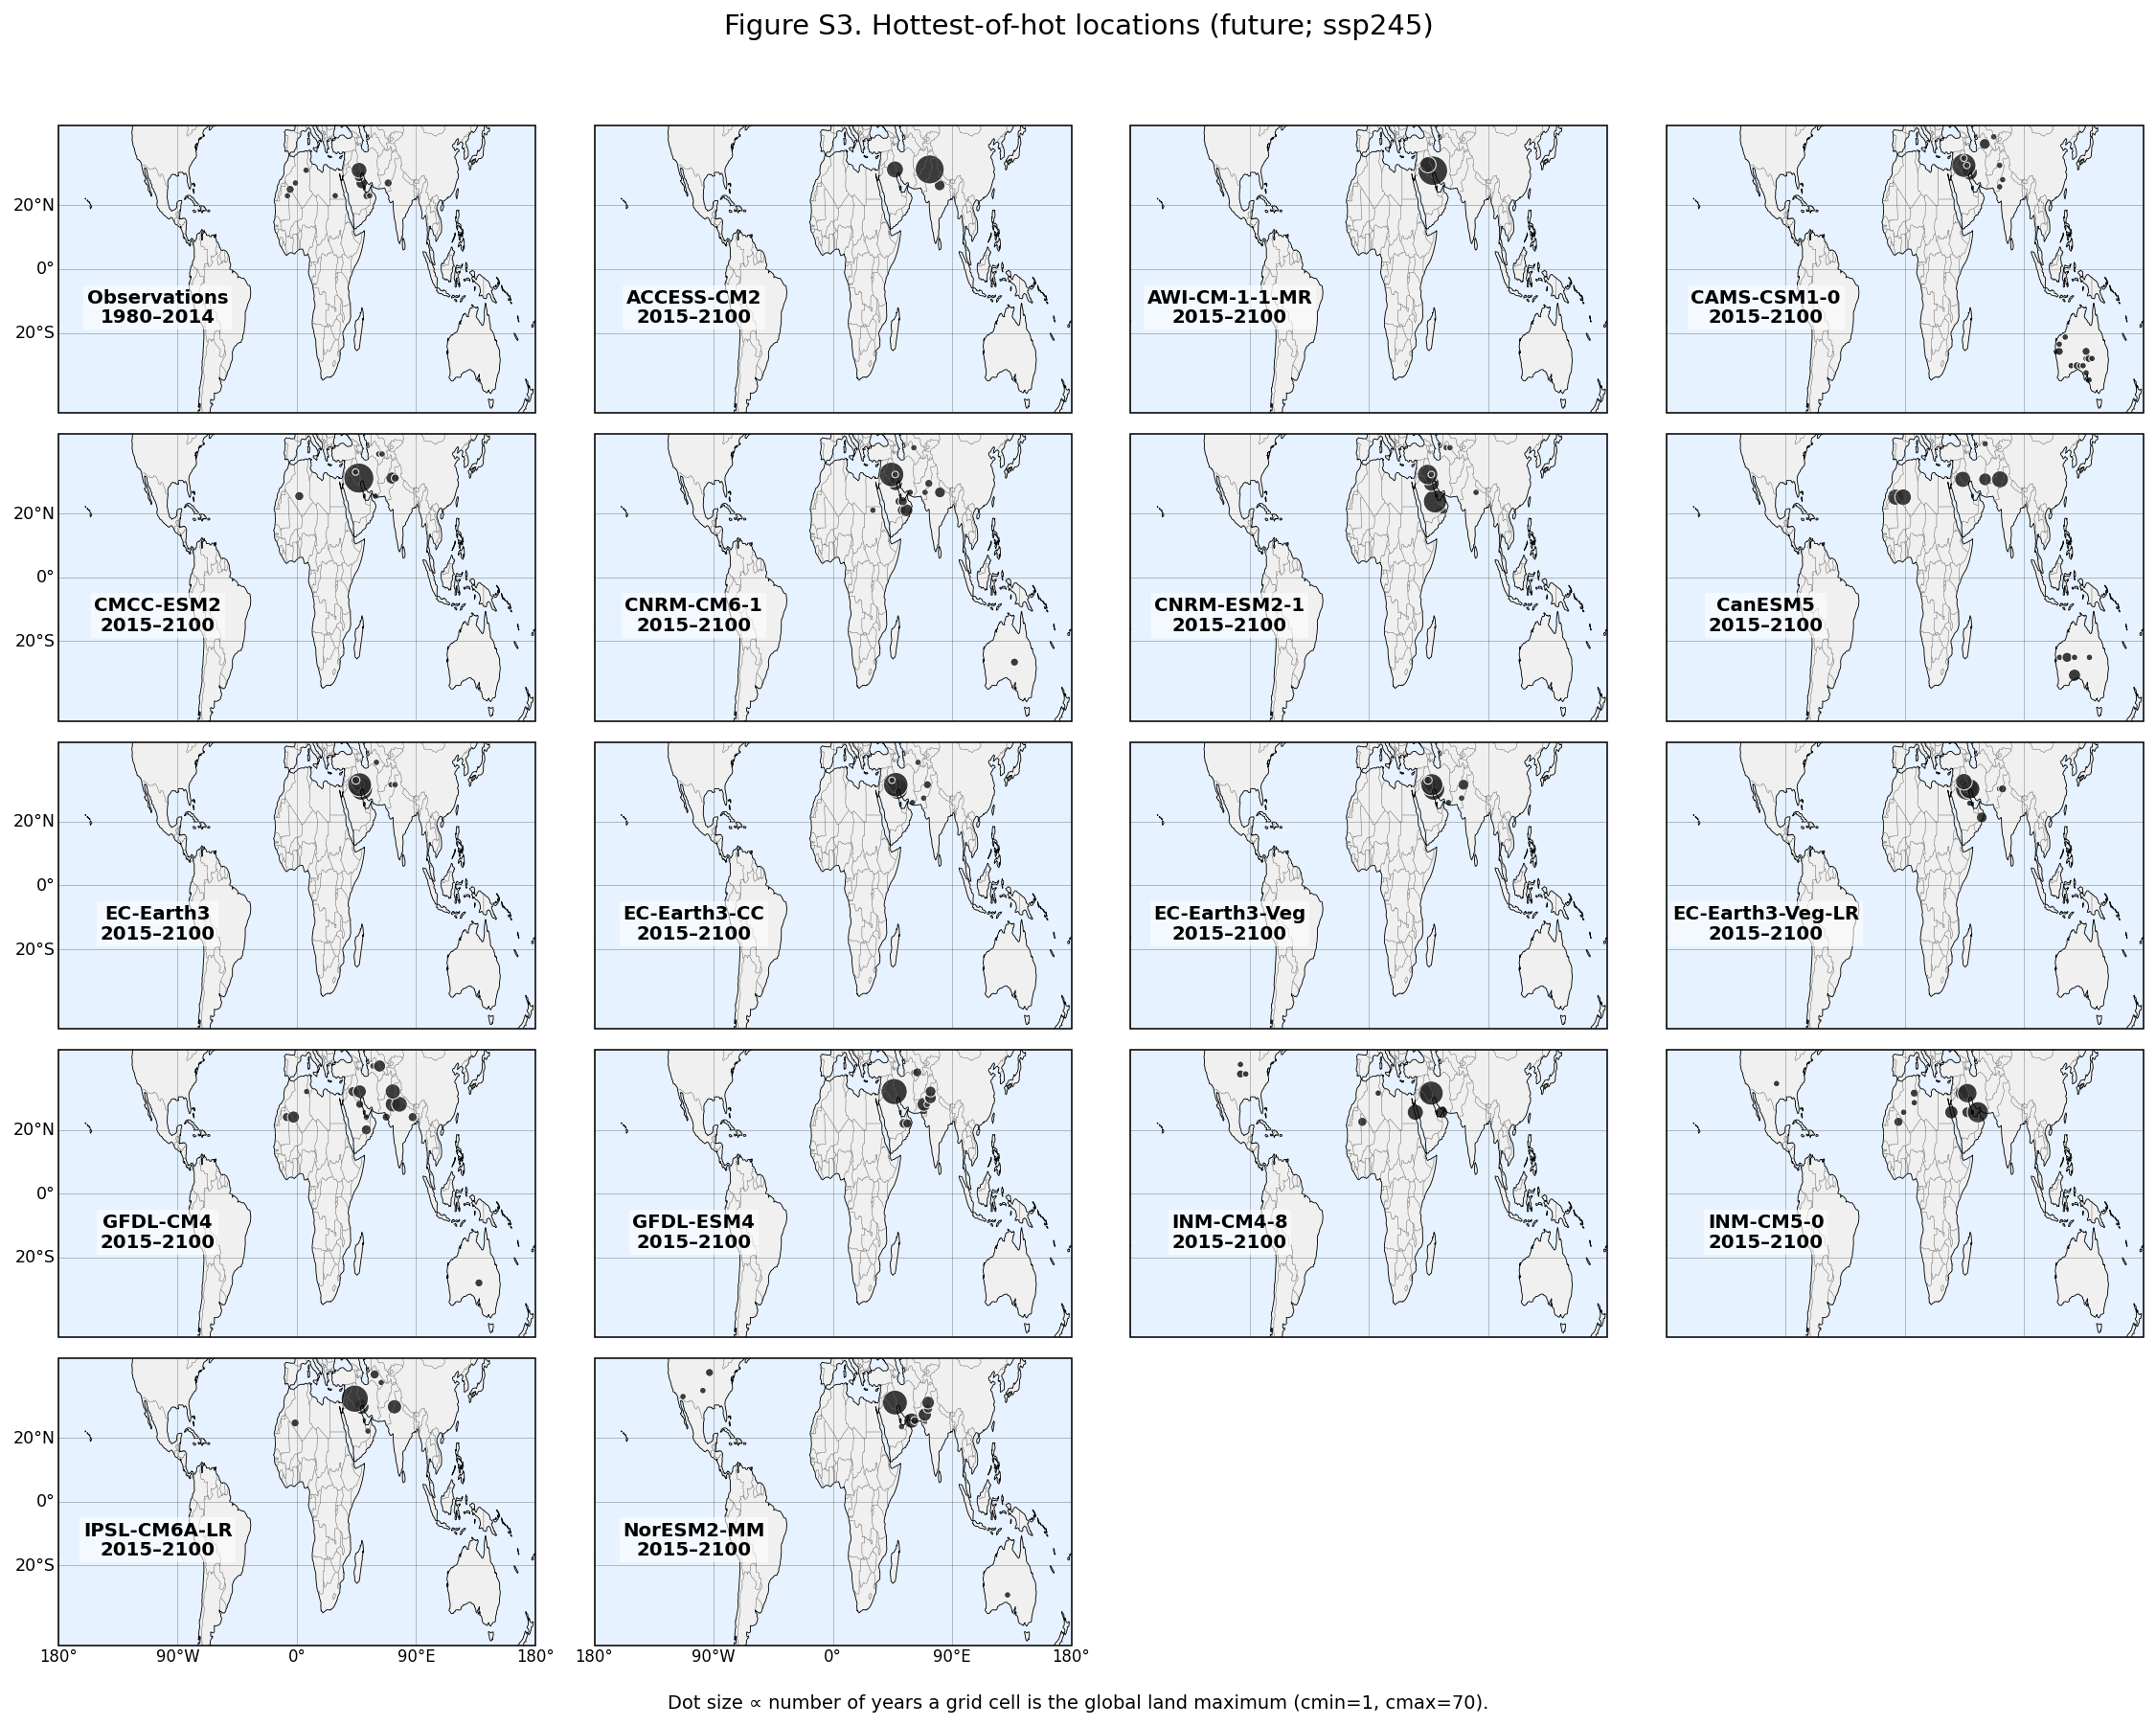

Saved: /content/drive/MyDrive/climate_work/output_supp_hotspots/FigS3_hotspots_future_ssp245_2015-2100.png
Saved metrics: /content/drive/MyDrive/climate_work/output_supp_hotspots/hotspot_similarity_metrics.csv


,model,sim_hist_to_obs,sim_fut_to_obs,sim_hist_to_fut
1,AWI-CM-1-1-MR,0.860013,0.860013,1.000000
8,EC-Earth3-CC,0.514975,0.587103,0.989442
10,EC-Earth3-Veg-LR,0.483895,0.482755,0.794788
3,CMCC-ESM2,0.475224,0.388848,0.595572
13,INM-CM4-8,0.326408,0.309080,0.953296
9,EC-Earth3-Veg,0.284230,0.434198,0.795738
14,INM-CM5-0,0.144124,0.233632,0.812882
5,CNRM-ESM2-1,0.121081,0.047538,0.899700
2,CAMS-CSM1-0,0.083424,0.034828,0.378816
16,NorESM2-MM,0.076877,0.154074,0.471073


In [3]:
# ============================ INSTALLS (if fresh Colab) ============================
# !pip -q install xarray pandas regionmask gcsfs zarr fsspec intake intake-esm dask > /dev/null

# ============================ MOUNT GOOGLE DRIVE (Colab) ============================
from google.colab import drive
drive.mount("/content/drive")

# ============================ IMPORTS ============================
import os, gc, shutil
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import intake

try:
    import dask
    dask.config.set(scheduler="threads")
except Exception:
    pass

# ----------------- SETTINGS -----------------
WORKDIR = "/content/drive/MyDrive/climate_work"

# Berkeley files (your same pattern)
BERKELEY_FILES = [
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_1980.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_1990.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_2000.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_2010.nc",
]

HIST0, HIST1 = "1980-01-01", "2014-12-31"
FUT0,  FUT1  = "2015-01-01", "2100-12-31"
SCENARIO = "ssp245"

LAT_MIN, LAT_MAX = -45, 45

# Chunking
TIME_CHUNK_DAYS = 365
LAT_CHUNK = 180
LON_CHUNK = 180

# Hotspot coarsen (big speed win; 2 is usually fine)
HOTSPOT_COARSEN = 2

# Models to include in the supplementary figures
# (Put your full CMIP6 set here; keep it to what you actually used in the paper.)
MODELS = [
    "ACCESS-CM2","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-ESM2","CNRM-CM6-1","CNRM-ESM2-1",
    "CanESM5","EC-Earth3","EC-Earth3-CC","EC-Earth3-Veg","EC-Earth3-Veg-LR",
    "GFDL-CM4","GFDL-ESM4","INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-MM"
]

# If you have a CSV of model accuracy (RMSE etc.), point to it here (optional).
# Expected columns: model, rmse (or bias/r2). If not provided, it will keep MODELS order.
ACCURACY_CSV = None  # e.g., f"{WORKDIR}/model_skill_table.csv"
ACCURACY_COL = "rmse"  # sort ascending

# Output
OUTDIR = f"{WORKDIR}/output_supp_hotspots"
os.makedirs(OUTDIR, exist_ok=True)

OUT_S2 = f"{OUTDIR}/FigS2_hotspots_historical_{HIST0[:4]}-{HIST1[:4]}.png"
OUT_S3 = f"{OUTDIR}/FigS3_hotspots_future_{SCENARIO}_{FUT0[:4]}-{FUT1[:4]}.png"
OUT_METRICS = f"{OUTDIR}/hotspot_similarity_metrics.csv"

# Caching yearmax results (recommended)
CACHE_DIR = f"{OUTDIR}/cache_yearmax"
os.makedirs(CACHE_DIR, exist_ok=True)

# ----------------- PLOTTING STYLE -----------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10.5,
    "axes.titlesize": 11.0,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

DOT_COLOR = "#2b2b2b"
DOT_EDGE  = "white"
DOT_EW    = 0.55
DOT_ALPHA = 0.92

S_MIN, S_MAX = 12, 260
GAMMA = 0.85

# ----------------- HELPERS -----------------
def normalize_coords(ds):
    if "latitude"  in ds.coords: ds = ds.rename({"latitude": "lat"})
    if "longitude" in ds.coords: ds = ds.rename({"longitude":"lon"})
    if "lon" in ds.coords:
        lon = xr.where(ds["lon"] > 180, ds["lon"] - 360, ds["lon"])
        ds  = ds.assign_coords(lon=lon).sortby("lon")
    if "lat" in ds.coords and ds.lat.size > 1 and float(ds.lat[0]) > float(ds.lat[-1]):
        ds = ds.sortby("lat")
    return ds

def open_one_localcopy(path):
    p = f"/content/{os.path.basename(path)}"
    if not os.path.exists(p) or os.path.getsize(p) != os.path.getsize(path):
        shutil.copy2(path, p)
    last = None
    for eng in ["h5netcdf","netcdf4","scipy"]:
        try:
            kw = dict(chunks={"time":90, "lat":LAT_CHUNK, "lon":LON_CHUNK})
            if eng=="h5netcdf":
                return xr.open_dataset(p, engine=eng, backend_kwargs={"invalid_netcdf":True}, **kw)
            elif eng=="netcdf4":
                return xr.open_dataset(p, engine=eng, **kw)
            else:
                return xr.open_dataset(p, engine=eng)
        except Exception as e:
            last = e
    raise last

def ensure_datetime_time(ds, t0):
    if "time" in ds.dims and "time" in ds.coords:
        return ds
    n = ds.sizes["time"]
    t = pd.date_range(t0, periods=n, freq="D")
    return ds.assign_coords(time=("time", t))

def maybe_coarsen_latlon(da, factor):
    if factor is None or int(factor) <= 1:
        return da
    f = int(factor)
    return da.coarsen(lat=f, lon=f, boundary="trim").mean()

def interp_mask_to(landmask_ref, lat, lon, method="nearest"):
    lm = landmask_ref
    if "latitude"  in lm.coords: lm = lm.rename({"latitude":"lat"})
    if "longitude" in lm.coords: lm = lm.rename({"longitude":"lon"})
    if float(lm.lon.max()) > 180:
        lm = lm.assign_coords(lon=xr.where(lm.lon > 180, lm.lon - 360, lm.lon)).sortby("lon")
    return lm.interp(lat=lat, lon=lon, method=method)

def plot_base(ax):
    ax.set_extent([-180, 180, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    ax.set_facecolor("#e6f2ff")
    ax.add_feature(cfeature.LAND,  facecolor="#f0f0f0")
    ax.add_feature(cfeature.OCEAN, facecolor="#e6f2ff")
    ax.coastlines(resolution="110m", linewidth=0.45)
    ax.add_feature(cfeature.BORDERS, linewidth=0.25, edgecolor="0.4")
    for s in ["left","right","bottom","top"]:
        ax.spines[s].set_linewidth(0.45)

def add_geo_labels(ax, show_left=False, show_bottom=False):
    meridians = [-180, -90, 0, 90, 180]
    parallels = [-20, 0, 20]
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      xlocs=meridians, ylocs=parallels,
                      linewidth=0.35, color="0.35", alpha=0.55, linestyle="-", zorder=6)
    gl.rotate_labels = False
    gl.xformatter = LongitudeFormatter(number_format=".0f", degree_symbol="°")
    gl.yformatter = LatitudeFormatter(number_format=".0f", degree_symbol="°")
    gl.top_labels = False; gl.right_labels = False
    gl.left_labels = bool(show_left); gl.bottom_labels = bool(show_bottom)
    gl.xlabel_style = dict(size=8.5, weight="normal")
    gl.ylabel_style = dict(size=9.0, weight="normal")
    gl.xpadding = 1.5; gl.ypadding = 1.5

def shared_size_map(counts, cmin, cmax, smin=S_MIN, smax=S_MAX, gamma=GAMMA):
    counts = np.asarray(counts, float)
    if cmax <= cmin:
        return np.full_like(counts, (smin+smax)/2)
    x = (counts - cmin) / (cmax - cmin)
    x = np.clip(x, 0, 1) ** gamma
    return smin + x * (smax - smin)

# ---- HOTTEST-OF-HOT: annual global max locations -> counts ----
def yearmax_locations_df(da_time_lat_lon, coarsen_factor=1):
    da = da_time_lat_lon.sel(lat=slice(LAT_MIN, LAT_MAX))
    da = maybe_coarsen_latlon(da, coarsen_factor)

    annmax = da.groupby("time.year").max("time")  # (year, lat, lon)
    annmax = annmax.chunk({"year": 1, "lat": LAT_CHUNK, "lon": LON_CHUNK})

    stacked = annmax.stack(space=("lat","lon"))
    imax = stacked.argmax("space").compute()
    vmax = stacked.max("space").compute()

    years = imax["year"].values.astype(int)
    nlat, nlon = int(annmax.sizes["lat"]), int(annmax.sizes["lon"])
    flat = np.asarray(imax.values).astype(int).ravel()
    ilat, ilon = np.unravel_index(flat, (nlat, nlon))

    latv = annmax["lat"].values.astype(float)
    lonv = annmax["lon"].values.astype(float)

    lats = latv[ilat].astype(float).ravel()
    lons = lonv[ilon].astype(float).ravel()
    vals = np.asarray(vmax.values).astype(float).ravel()

    return pd.DataFrame({"year": years, "lat": lats, "lon": lons, "value": vals}).sort_values("year")

def hotspot_counts_df(df_yearmax):
    hs = (df_yearmax.groupby(["lat","lon"], as_index=False)
            .agg(count=("year","size"),
                 max_value=("value","max"),
                 first_year=("year","min"),
                 last_year=("year","max")))
    hs["count"] = hs["count"].astype(int)
    return hs

def hs_to_field(hs_df, lat_vals, lon_vals):
    """Put hotspot counts onto a (lat,lon) field matching the coarsened grid."""
    field = np.zeros((len(lat_vals), len(lon_vals)), dtype=float)
    if hs_df is None or len(hs_df) == 0:
        return xr.DataArray(field, coords={"lat": lat_vals, "lon": lon_vals}, dims=("lat","lon"))
    lat_to_i = {float(v): i for i, v in enumerate(lat_vals)}
    lon_to_j = {float(v): j for j, v in enumerate(lon_vals)}
    for _, r in hs_df.iterrows():
        i = lat_to_i.get(float(r["lat"]), None)
        j = lon_to_j.get(float(r["lon"]), None)
        if i is not None and j is not None:
            field[i, j] = float(r["count"])
    return xr.DataArray(field, coords={"lat": lat_vals, "lon": lon_vals}, dims=("lat","lon"))

def plot_hotspots(ax, hs_df, cmin, cmax):
    plot_base(ax)
    if hs_df is None or len(hs_df)==0:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=9.5, color="0.4")
        return
    counts = hs_df["count"].to_numpy().astype(float)
    sizes  = shared_size_map(counts, cmin, cmax)
    ax.scatter(hs_df["lon"].to_numpy(), hs_df["lat"].to_numpy(),
               s=sizes, c=DOT_COLOR, alpha=DOT_ALPHA,
               edgecolor=DOT_EDGE, linewidth=DOT_EW,
               transform=ccrs.PlateCarree())

def add_panel_label(ax, title, years, x=-105, y=-18):
    ax.text(x, y, f"{title}\n{years}",
            transform=ccrs.PlateCarree(),
            ha="center", va="bottom",
            fontsize=10.2, fontweight="bold",
            linespacing=1.12,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.60, pad=1.8),
            zorder=5)

# ----------------- OPEN OBS / BUILD ABS Tmax -----------------
print("Opening Berkeley files...")
opened = [normalize_coords(open_one_localcopy(f)) for f in BERKELEY_FILES]
dsb = xr.concat(opened, dim="time", data_vars="minimal", coords="minimal", compat="override")

try:
    from xarray.coders import CFDatetimeCoder
except Exception:
    try:
        from xarray.coding.times import CFDatetimeCoder
    except Exception:
        CFDatetimeCoder = None

if CFDatetimeCoder is not None:
    time_coder = CFDatetimeCoder(use_cftime=True)
    dsb = xr.decode_cf(dsb, decode_times=time_coder, mask_and_scale=True).sortby("time")
else:
    dsb = xr.decode_cf(dsb, use_cftime=True, mask_and_scale=True).sortby("time")

dsb = ensure_datetime_time(dsb, HIST0).sel(time=slice(HIST0, HIST1))

anom = dsb["temperature"]
clim = dsb["climatology"]
doy  = dsb["day_of_year"]

lmask_ref = dsb.get("land_mask")
if lmask_ref is None:
    # fallback: land where climatology exists
    lmask_ref = xr.where(~xr.ufuncs.isnan(clim.isel(time=0) if "time" in clim.dims else clim.isel(dayofyear=0)),
                         1.0, 0.0)

# align climatology dimension name
if "day_number" in clim.dims: clim = clim.rename({"day_number":"dayofyear"})
elif "day_of_year" in clim.dims: clim = clim.rename({"day_of_year":"dayofyear"})
elif "time" in clim.dims and clim.sizes["time"] in (365, 366): clim = clim.rename({"time":"dayofyear"})

doy_i   = xr.where(doy > 365, 365, doy).astype("int32")
start   = int(np.nanmin(clim["dayofyear"].values))
indexer = xr.where(doy_i > 365, 364, doy_i - 1) if start == 0 else doy_i
clim_sel = clim.sel(dayofyear=indexer)

Tmax_abs_hist_obs = (anom + clim_sel).rename("Tmax_abs").where(lmask_ref > 0.5)
Tmax_abs_hist_obs = Tmax_abs_hist_obs.chunk({"time": TIME_CHUNK_DAYS, "lat": LAT_CHUNK, "lon": LON_CHUNK})

print("Computing OBS hotspots (1980–2014)...")
cache_obs = os.path.join(CACHE_DIR, f"OBS_yearmax_{HIST0[:4]}_{HIST1[:4]}_coarsen{HOTSPOT_COARSEN}.csv")
if os.path.exists(cache_obs):
    df_obs_yearmax = pd.read_csv(cache_obs)
else:
    df_obs_yearmax = yearmax_locations_df(Tmax_abs_hist_obs, coarsen_factor=HOTSPOT_COARSEN)
    df_obs_yearmax.to_csv(cache_obs, index=False)

hs_obs = hotspot_counts_df(df_obs_yearmax)

# ----------------- CMIP6 LOADING (catalog once) -----------------
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")

def choose_member_id(cat):
    mids = sorted(list(set(cat.df["member_id"].values.tolist())))
    return mids[0] if len(mids) else "r1i1p1f1"

def load_model_tasmax(source_id, experiment_id, t0, t1):
    cat = col.search(
        source_id=source_id,
        experiment_id=experiment_id,
        table_id="day",
        variable_id="tasmax",
    )
    if cat.df is None or len(cat.df)==0:
        raise ValueError(f"No entries for {source_id} {experiment_id} day tasmax")

    mid = choose_member_id(cat)
    cat = col.search(
        source_id=source_id,
        experiment_id=experiment_id,
        table_id="day",
        variable_id="tasmax",
        member_id=mid,
    )

    dsets = cat.to_dataset_dict(
        zarr_kwargs={"consolidated": True, "use_cftime": True},
        storage_options={"token": "anon"}
    )
    if not dsets:
        raise ValueError(f"No dataset found for {source_id} {experiment_id} day tasmax ({mid})")

    ds = normalize_coords(list(dsets.values())[0])
    tas = ds["tasmax"].sel(time=slice(t0, t1))
    tas = tas.chunk({"time": TIME_CHUNK_DAYS, "lat": LAT_CHUNK, "lon": LON_CHUNK})

    u = str(tas.attrs.get("units","")).lower()
    if u in ["k","kelvin"] or float(tas.isel(time=0).max()) > 200:
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"
    tas.attrs["member_id_used"] = mid
    return tas

def compute_model_hotspots(model, experiment, t0, t1):
    # cache by model/exp/window/coarsen
    cache = os.path.join(CACHE_DIR, f"{model}_{experiment}_{t0[:4]}_{t1[:4]}_coarsen{HOTSPOT_COARSEN}.csv")
    if os.path.exists(cache):
        df = pd.read_csv(cache)
        hs = hotspot_counts_df(df)
        return hs, df

    tas = load_model_tasmax(model, experiment, t0, t1)
    mask = interp_mask_to(lmask_ref, lat=tas.lat, lon=tas.lon, method="nearest")
    tas_land = tas.where(mask > 0.5)

    df = yearmax_locations_df(tas_land, coarsen_factor=HOTSPOT_COARSEN)
    df.to_csv(cache, index=False)
    hs = hotspot_counts_df(df)
    return hs, df

# ----------------- OPTIONAL: sort models by accuracy -----------------
models_ordered = MODELS.copy()
if ACCURACY_CSV is not None and os.path.exists(ACCURACY_CSV):
    skill = pd.read_csv(ACCURACY_CSV)
    if "model" in skill.columns and ACCURACY_COL in skill.columns:
        skill = skill.dropna(subset=["model", ACCURACY_COL])
        good = [m for m in MODELS if m in set(skill["model"])]
        skill = skill.set_index("model").loc[good].sort_values(ACCURACY_COL, ascending=True).reset_index()
        models_ordered = skill["model"].tolist()
        print("Sorted models by", ACCURACY_COL)

# ----------------- COMPUTE HOTSPOTS FOR ALL MODELS -----------------
hs_hist = {}
hs_fut  = {}
meta = []

print("Computing model hotspots for historical + future...")
for m in models_ordered:
    for exp, (t0,t1), store in [
        ("historical", (HIST0, HIST1), hs_hist),
        (SCENARIO,     (FUT0,  FUT1),  hs_fut)
    ]:
        try:
            hs, df = compute_model_hotspots(m, exp, t0, t1)
            store[m] = hs
            meta.append((m, exp, len(df)))
            print(f"  {m:14s} {exp:10s}  years={df['year'].nunique():3d}  cachedOK")
        except Exception as e:
            store[m] = None
            print(f"  {m:14s} {exp:10s}  FAILED: {e}")

# ----------------- COMMON DOT SCALE (across OBS + ALL MODELS) -----------------
def compute_cmin_cmax(hs_list):
    counts = []
    for hs in hs_list:
        if hs is not None and len(hs):
            counts.extend(hs["count"].to_numpy().tolist())
    if len(counts)==0:
        return 1, 1
    return max(1, int(np.min(counts))), int(np.max(counts))

cmin_hist, cmax_hist = compute_cmin_cmax([hs_obs] + [hs_hist[m] for m in models_ordered])
cmin_fut,  cmax_fut  = compute_cmin_cmax([hs_obs] + [hs_fut[m]  for m in models_ordered])

# ----------------- MAKE SMALL-MULTIPLES FIGURE -----------------
def plot_supp_hotspots(filename, title, years_label, hs_models, cmin, cmax, include_obs=True):
    # layout: 1 (obs) + N models; choose columns to look like a supplement figure
    panels = (1 if include_obs else 0) + len(models_ordered)
    ncols = 4
    nrows = int(np.ceil(panels / ncols))

    fig = plt.figure(figsize=(4.05*ncols, 2.6*nrows))
    fig.suptitle(title, fontsize=15, y=0.99)

    proj = ccrs.PlateCarree()

    idx = 0
    if include_obs:
        ax = fig.add_subplot(nrows, ncols, 1, projection=proj)
        plot_hotspots(ax, hs_obs, cmin, cmax)
        add_panel_label(ax, "Observations", "1980–2014")
        add_geo_labels(ax, show_left=True, show_bottom=(nrows==1))
        idx = 1

    for k, m in enumerate(models_ordered):
        ax = fig.add_subplot(nrows, ncols, idx+1, projection=proj)
        plot_hotspots(ax, hs_models.get(m, None), cmin, cmax)
        add_panel_label(ax, m, years_label)

        is_left = ((idx) % ncols == 0)
        is_bottom = (idx // ncols == nrows-1)
        add_geo_labels(ax, show_left=is_left, show_bottom=is_bottom)
        idx += 1

    # small note (dot scale)
    fig.text(0.5, 0.015, f"Dot size ∝ number of years a grid cell is the global land maximum (cmin={cmin}, cmax={cmax}).",
             ha="center", va="bottom", fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.965])
    plt.savefig(filename, bbox_inches="tight", pad_inches=0.10)
    plt.show()
    print("Saved:", filename)

plot_supp_hotspots(
    OUT_S2,
    title="Figure S2. Hottest-of-hot locations (historical)",
    years_label="1980–2014",
    hs_models=hs_hist,
    cmin=cmin_hist, cmax=cmax_hist,
    include_obs=True
)

plot_supp_hotspots(
    OUT_S3,
    title=f"Figure S3. Hottest-of-hot locations (future; {SCENARIO})",
    years_label="2015–2100",
    hs_models=hs_fut,
    cmin=cmin_fut, cmax=cmax_fut,
    include_obs=True
)

# ----------------- METRICS: similarity to obs + hist→future stability -----------------
def cosine_similarity(a, b, eps=1e-12):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    return float(np.dot(a, b) / (na*nb + eps))

def spatial_corr(a, b):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
        if np.std(a)==0 or np.std(b)==0:
            return np.nan
        return float(np.corrcoef(a, b)[0,1])
    return np.nan

# obs reference grid for hotspot fields: use coarsened obs grid
# (derive by applying same coarsen to obs lat/lon)
obs_lat = maybe_coarsen_latlon(Tmax_abs_hist_obs.isel(time=0).drop_vars("time", errors="ignore"), HOTSPOT_COARSEN).lat.values
obs_lon = maybe_coarsen_latlon(Tmax_abs_hist_obs.isel(time=0).drop_vars("time", errors="ignore"), HOTSPOT_COARSEN).lon.values

obs_field = hs_to_field(hs_obs, obs_lat, obs_lon)
obs_prob  = (obs_field / (obs_field.sum() + 1e-12)).values

rows = []
for m in models_ordered:
    hsh = hs_hist.get(m, None)
    hsf = hs_fut.get(m, None)

    # fields (on their own grids) -> interpolate to obs coarsened grid for comparison
    def field_on_obs(hs_df):
        if hs_df is None or len(hs_df)==0:
            return np.zeros_like(obs_prob)
        # build field on the model's own (coarsened) grid then interpolate to obs
        lat_vals = np.sort(hs_df["lat"].unique())
        lon_vals = np.sort(hs_df["lon"].unique())
        fld = hs_to_field(hs_df, lat_vals, lon_vals)
        # make it a DataArray and interp to obs grid
        fld = fld.interp(lat=obs_lat, lon=obs_lon, method="nearest")
        fld = fld.fillna(0.0)
        prob = (fld / (fld.sum() + 1e-12)).values
        return prob

    ph = field_on_obs(hsh)
    pf = field_on_obs(hsf)

    sim_hist = cosine_similarity(ph, obs_prob)
    sim_fut  = cosine_similarity(pf, obs_prob)

    # stability: hist vs future similarity
    stab = cosine_similarity(ph, pf)

    rows.append(dict(
        model=m,
        sim_hist_to_obs=sim_hist,
        sim_fut_to_obs=sim_fut,
        sim_hist_to_fut=stab
    ))

metrics = pd.DataFrame(rows)
metrics.to_csv(OUT_METRICS, index=False)
print("Saved metrics:", OUT_METRICS)
display(metrics.sort_values("sim_hist_to_obs", ascending=False).head(10))

# ----------------- OPTIONAL: quick scatter (if you have RMSE table) -----------------
if ACCURACY_CSV is not None and os.path.exists(ACCURACY_CSV):
    skill = pd.read_csv(ACCURACY_CSV)
    if "model" in skill.columns and ACCURACY_COL in skill.columns:
        df = metrics.merge(skill[["model", ACCURACY_COL]], on="model", how="inner")
        plt.figure(figsize=(6.4, 4.8))
        plt.scatter(df[ACCURACY_COL].values, df["sim_hist_to_obs"].values)
        plt.xlabel(ACCURACY_COL)
        plt.ylabel("hotspot similarity to obs (historical)")
        plt.title("Do more accurate models place hotspots more like obs?")
        plt.grid(True, alpha=0.3, linestyle="--")
        plt.show()


In [3]:
# ============================================================
# ALLOWED-only Option A: cache p99(tasmax) for 1980–2014
# - Uses Pangeo CMIP6 catalog
# - Only runs models in ALLOWED
# - Writes one cached NetCDF per model (fast resume)
# ============================================================

import os, gc, glob
import numpy as np
import xarray as xr
import intake
import matplotlib.pyplot as plt

# ---------------- Colab Drive mount (safe) ----------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ---------------- Paths ----------------
WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"
CACHE_DIR  = f"{OUTPUT_DIR}/p99_cache_hist1980_2014"
QUICKLOOK_DIR = f"{OUTPUT_DIR}/p99_quicklooks"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(QUICKLOOK_DIR, exist_ok=True)

print("[info] WORKDIR:", WORKDIR)
print("[info] OUTPUT_DIR:", OUTPUT_DIR)
print("[info] CACHE_DIR:", CACHE_DIR)

# ---------------- Catalog ----------------
PANGEOCAT = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
col = intake.open_esm_datastore(PANGEOCAT)

# ---------------- USER SETTINGS ----------------
ALLOWED = sorted({
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
})

# resume controls
START_AT = 0      # set to e.g. 10 to resume from there in ALLOWED ordering
STOP_AT  = None   # or set an int to stop early for testing
BATCH_SIZE = 6    # keep small to avoid crashes; raise to 10 if stable

# computation controls
Q99 = 0.99
TIME_SLICE = ("1980-01-01", "2014-12-31")
LAT_SLICE  = (-45, 45)     # subset early for speed/memory
ZARR_CHUNKS = {"time": 90} # if stable, increase to 120; if crash, drop to 60

# member preference (keeps results consistent)
PREF_MEMBER_ORDER = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f3"]

# optional quicklook images (turn off for max speed)
MAKE_QUICKLOOKS = False

# ---------------- Helpers ----------------
def normalize_latlon(obj):
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords:
        obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat", "lon")]
    if extra:
        da = da.mean(dim=extra)
    if "lat" in da.coords and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def choose_row_for_model(df_model):
    """
    df_model: rows for a single source_id after catalog search
    Prefer a stable member if possible; otherwise first row.
    """
    d = df_model[["member_id", "grid_label", "zstore"]].drop_duplicates().reset_index(drop=True)
    for pref in PREF_MEMBER_ORDER:
        hit = d[d["member_id"] == pref]
        if len(hit) > 0:
            row = hit.iloc[0]
            return row["zstore"], row["member_id"], row["grid_label"]
    row = d.iloc[0]
    return row["zstore"], row["member_id"], row["grid_label"]

def open_p99_from_zstore(zurl):
    ds = xr.open_zarr(
        zurl,
        consolidated=True,
        storage_options={"token": "anon"},
        chunks=ZARR_CHUNKS
    )
    ds = normalize_latlon(ds)

    tas = ds["tasmax"].sel(time=slice(*TIME_SLICE))
    if "lat" in tas.coords:
        tas = tas.sel(lat=slice(LAT_SLICE[0], LAT_SLICE[1]))

    # Kelvin -> C heuristic (cheap, one-slice)
    sample = tas.isel(time=0).compute()
    if float(sample.max()) > 200:
        tas = tas - 273.15
        tas.attrs["units"] = "degC"

    tas = tas.astype("float32")
    p99 = tas.quantile(Q99, dim="time", skipna=True)
    return to_latlon_2d(p99)

def save_p99_nc(p99, out_nc):
    p99 = to_latlon_2d(p99).astype("float32")
    xr.Dataset({"p99_tasmax": p99}).to_netcdf(out_nc)

def quicklook_png(p99, title, out_png):
    da = to_latlon_2d(p99)
    plt.figure(figsize=(10,4))
    da.plot(cmap="inferno", add_colorbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close()

# ---------------- Pre-filter catalog ONCE ----------------
cat = col.search(experiment_id="historical", table_id="day", variable_id="tasmax")
df_all = cat.df.copy()

# restrict to ALLOWED only (this is what you want)
df_allowed = df_all[df_all["source_id"].isin(ALLOWED)].copy()
present = sorted(df_allowed["source_id"].unique().tolist())
missing = sorted(list(set(ALLOWED) - set(present)))

print(f"[info] ALLOWED total: {len(ALLOWED)}")
print(f"[info] Found in catalog (historical/day/tasmax): {len(present)}")
if missing:
    print(f"[warn] Missing from catalog query (will be skipped): {missing}")

# list of models to attempt (only ALLOWED, in your sorted order)
to_run = [m for m in ALLOWED if m in present]
to_run = to_run[START_AT:STOP_AT]

print(f"[info] Will attempt N={len(to_run)} models (ALLOWED-only).")
print("       First few:", to_run[:8])

# ---------------- Main loop (batched) ----------------
for b0 in range(0, len(to_run), BATCH_SIZE):
    batch = to_run[b0:b0+BATCH_SIZE]
    print(f"\n===== Batch {b0}–{b0+len(batch)-1} / {len(to_run)-1} =====")

    for model in batch:
        out_nc  = os.path.join(CACHE_DIR, f"{model}_p99_tasmax_hist1980_2014.nc")
        out_png = os.path.join(QUICKLOOK_DIR, f"{model}_p99_tasmax_hist1980_2014.png")

        if os.path.exists(out_nc):
            print(f"[cached] {model}")
            continue

        try:
            df_m = df_allowed[df_allowed["source_id"] == model]
            if len(df_m) == 0:
                print(f"[skip] {model}: no rows after ALLOWED filter")
                continue

            zurl, member, grid = choose_row_for_model(df_m)
            print(f"[compute] {model} ({member}, {grid})")

            p99 = open_p99_from_zstore(zurl)
            save_p99_nc(p99, out_nc)
            print("  saved:", out_nc)

            if MAKE_QUICKLOOKS:
                quicklook_png(p99, f"{model} p99(tasmax) 1980–2014", out_png)

            del p99
            gc.collect()

        except Exception as e:
            print(f"  [skip] {model}: {e}")
            gc.collect()

print("\n[done] caching pass complete.")
print("[info] cached files now:", len(glob.glob(os.path.join(CACHE_DIR, '*_p99_tasmax_hist1980_2014.nc'))))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[info] WORKDIR: /content/drive/MyDrive/climate_work
[info] OUTPUT_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99
[info] CACHE_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014
[info] ALLOWED total: 25
[info] Found in catalog (historical/day/tasmax): 21
[warn] Missing from catalog query (will be skipped): ['CMCC-CM2-SR5', 'HadGEM3-GC31-LL', 'IITM-ESM', 'UKESM1-0-LL']
[info] Will attempt N=21 models (ALLOWED-only).
       First few: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'CAMS-CSM1-0', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1']

===== Batch 0–5 / 20 =====
[cached] ACCESS-CM2
[cached] ACCESS-ESM1-5
[cached] AWI-CM-1-1-MR
[cached] CAMS-CSM1-0
[cached] CMCC-ESM2
[cached] CNRM-CM6-1

===== Batch 6–11 / 20 =====
[compute] CNRM-CM6-1-HR (r1i1p1f2, gr)


/tmp/ipython-input-2708130223.py:102: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


  saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014/CNRM-CM6-1-HR_p99_tasmax_hist1980_2014.nc
[compute] CNRM-ESM2-1 (r1i1p1f2, gr)


/tmp/ipython-input-2708130223.py:102: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


  saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014/CNRM-ESM2-1_p99_tasmax_hist1980_2014.nc
[compute] CanESM5 (r1i1p1f1, gn)


...

  saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014/NorESM2-LM_p99_tasmax_hist1980_2014.nc
[compute] NorESM2-MM (r1i1p1f1, gn)


/tmp/ipython-input-2708130223.py:102: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


  saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014/NorESM2-MM_p99_tasmax_hist1980_2014.nc
[compute] TaiESM1 (r1i1p1f1, gn)


/tmp/ipython-input-2708130223.py:102: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


  saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014/TaiESM1_p99_tasmax_hist1980_2014.nc

[done] caching pass complete.
[info] cached files now: 21


In [6]:
# ============================================================
# PASS B (cache-only): metrics + Table PNG + stamp figure
# Uses cached model p99(tasmax) maps from Pass A
# ============================================================

import os, glob, gc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------- Colab Drive mount (safe) ----------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ---------------- Paths (match Pass A) ----------------
WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"
CACHE_DIR  = f"{OUTPUT_DIR}/p99_cache_hist1980_2014"
FIG_DIR    = f"{OUTPUT_DIR}/passB_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Berkeley 99th percentile file (absolute °C)
BERKELEY_P99_PATH = f"{WORKDIR}/historical_output/tmax_99th_percentile.nc"
BERKELEY_VAR_NAME = "tmax_99th_percentile"  # fallback to sole variable if needed

# Outputs
METRICS_CSV = os.path.join(FIG_DIR, "cmip6_model_metrics_1980_2014_p99_centeredRMSE.csv")
TABLE_PNG   = os.path.join(FIG_DIR, "table1_metrics_relative_to_MMMmed.png")
STAMP_PNG   = os.path.join(FIG_DIR, "figS_p99_bias_stamp.png")

print("[info] CACHE_DIR:", CACHE_DIR)
print("[info] BERKELEY_P99_PATH:", BERKELEY_P99_PATH)
print("[info] FIG_DIR:", FIG_DIR)

# ---------------- Region settings ----------------
LAT_MIN, LAT_MAX = -45, 45      # metrics domain (Nick comment: coarse gridboxes)
PLOT_LAT_MIN, PLOT_LAT_MAX = -60, 60  # stamp plotting band
Q99_LABEL = "p99(tasmax), 1980–2014"

# ---------------- Helpers ----------------
def normalize_latlon(obj):
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords:
        obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra:
        da = da.mean(dim=extra)
    if "lat" in da.coords and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def maybe_K_to_C(da):
    da = da.astype("float32")
    # if values look like Kelvin, convert
    v = float(da.quantile(0.5).values)
    if np.isfinite(v) and v > 150:
        da = da - 273.15
    da.attrs["units"] = "degC"
    return da

def load_berkeley_p99(path, var_expected):
    ds = xr.open_dataset(path)
    if var_expected not in ds:
        vars_in = list(ds.data_vars)
        if len(vars_in) == 1:
            var_expected = vars_in[0]
            print(f"[info] Using sole variable in {os.path.basename(path)}: {var_expected}")
        else:
            raise KeyError(f"{var_expected} not found. Vars: {vars_in}")
    da = normalize_latlon(ds[var_expected])
    return to_latlon_2d(maybe_K_to_C(da))

def load_model_cached_p99(nc_path):
    ds = xr.open_dataset(nc_path)
    # Pass A saved var name "p99_tasmax"
    if "p99_tasmax" in ds:
        da = ds["p99_tasmax"]
    else:
        # fallback if something changed
        da = ds.to_array().squeeze(drop=True)
    da = to_latlon_2d(maybe_K_to_C(da))
    return da

def calc_spatial_r2(model_da, obs_da):
    m = model_da.values.ravel()
    o = obs_da.values.ravel()
    mask = np.isfinite(m) & np.isfinite(o)
    if mask.sum() < 10:
        return np.nan
    m = m[mask]; o = o[mask]
    mm = m - m.mean()
    oo = o - o.mean()
    denom = np.sqrt((mm**2).sum() * (oo**2).sum())
    if denom == 0:
        return np.nan
    r = (mm * oo).sum() / denom
    return float(r**2)

def calc_metrics_centered_rmse(model_da, obs_da):
    model_da = to_latlon_2d(model_da)
    obs_da   = to_latlon_2d(obs_da)
    diff = model_da - obs_da
    bias = float(diff.mean().values)
    crmse = float((((diff - diff.mean())**2).mean())**0.5)
    r2 = calc_spatial_r2(model_da, obs_da)
    return crmse, bias, r2

# ---------------- Table plot (relative to MMM_median) ----------------
def plot_metrics_table_relative_to_median(df_metrics, out_png):
    df = df_metrics[["model", "crmse", "bias", "r2"]].copy()

    # multi-model summaries
    mmm = pd.Series({
        "crmse": df["crmse"].mean(),
        "bias":  df["bias"].mean(),
        "r2":    df["r2"].mean()
    })
    mmm_med = pd.Series({
        "crmse": df["crmse"].median(),
        "bias":  df["bias"].median(),
        "r2":    df["r2"].median()
    })

    df_table = df.copy()
    df_table = pd.concat([
        df_table,
        pd.DataFrame([{"model":"Multi-model mean",   "crmse": mmm["crmse"],     "bias": mmm["bias"],     "r2": mmm["r2"]}]),
        pd.DataFrame([{"model":"Multi-model median", "crmse": mmm_med["crmse"], "bias": mmm_med["bias"], "r2": mmm_med["r2"]}]),
    ], ignore_index=True)

    # shading relative to MMM_median
    ref_rmse = mmm_med["crmse"]
    ref_absb = abs(mmm_med["bias"])
    ref_r2   = mmm_med["r2"]

    # build table text
    cell_text = []
    for _, row in df_table.iterrows():
        cell_text.append([
            row["model"],
            f"{row['crmse']:.2f}",
            f"{row['bias']:+.2f}",
            f"{row['r2']:.3f}",
        ])

    col_labels = ["Model", "cRMSE (°C)", "Bias (°C)", r"Spatial $R^2$"]

    good = "#c6efce"
    bad  = "#f4cccc"
    header = "#d9d9d9"
    summary = "#e6e6e6"

    fig, ax = plt.subplots(figsize=(12, 0.35*len(df_table) + 1.5))
    ax.axis("off")
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1.0, 1.25)

    # header styling
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor(header)
        tbl[0, j].set_text_props(weight="bold")

    # row styling
    n = len(df_table)
    for i in range(n):
        r = df_table.iloc[i]
        row_idx = i + 1
        is_summary = (r["model"] in ["Multi-model mean", "Multi-model median"])

        for j in range(len(col_labels)):
            cell = tbl[row_idx, j]
            if is_summary:
                cell.set_facecolor(summary)
                cell.set_text_props(weight="bold")
                continue

            if j == 0:
                continue

            if j == 1:  # cRMSE smaller is better
                cell.set_facecolor(good if r["crmse"] <= ref_rmse else bad)
            elif j == 2:  # |bias| smaller is better
                cell.set_facecolor(good if abs(r["bias"]) <= ref_absb else bad)
            elif j == 3:  # R2 larger is better
                cell.set_facecolor(good if r["r2"] >= ref_r2 else bad)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("[saved] table:", out_png)

# ---------------- Stamp figure (bias maps) ----------------
def plot_bias_stamp(bias_fields, out_png, ncols=5, vlim=8.0, metrics_map=None):
    """
    bias_fields: list of (modelname, bias_da) on each model grid.
    We plot each bias on its own grid (no regridding), just for qualitative pattern.

    metrics_map: dict model -> (crmse, bias, r2) used to print values under model name.
    """
    n = len(bias_fields)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(3.6*ncols, 2.6*nrows))
    proj = ccrs.PlateCarree()

    for k, (name, da) in enumerate(bias_fields):
        ax = plt.subplot(nrows, ncols, k+1, projection=proj)
        ax.set_extent([-180, 180, PLOT_LAT_MIN, PLOT_LAT_MAX], crs=proj)
        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)

        # plot
        im = da.sel(lat=slice(PLOT_LAT_MIN, PLOT_LAT_MAX)).plot.pcolormesh(
            ax=ax, transform=proj, cmap="coolwarm",
            vmin=-vlim, vmax=vlim, add_colorbar=False
        )

        # title: model name + metrics line (right above plot)
        if metrics_map is not None and name in metrics_map:
            crmse, bias, r2 = metrics_map[name]
            ax.set_title(
                f"{name}\n"
                f"cRMSE={crmse:.2f}  Bias={bias:+.2f}  R²={r2:.3f}",
                fontsize=9,
                pad=2
            )
        else:
            ax.set_title(name, fontsize=9, pad=2)

        ax.set_xticks([]); ax.set_yticks([])

    # common colorbar
    cax = fig.add_axes([0.25, 0.06, 0.5, 0.02])
    cb = plt.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label("Model − Berkeley p99(tasmax) [°C]")

    plt.suptitle(f"Spatial bias patterns: {Q99_LABEL}", y=0.995, fontsize=14)
    plt.tight_layout(rect=[0, 0.08, 1, 0.97])
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("[saved] stamp:", out_png)

# ============================================================
# Main: read cache -> metrics -> table + stamp
# ============================================================

# 1) Find cached model p99 files
cached = sorted(glob.glob(os.path.join(CACHE_DIR, "*_p99_tasmax_hist1980_2014.nc")))
if len(cached) == 0:
    raise RuntimeError(f"No cached files found in {CACHE_DIR}. Did Pass A finish?")

# model list from cache filenames
models = [os.path.basename(p).replace("_p99_tasmax_hist1980_2014.nc", "") for p in cached]
print(f"[info] Cached models found: N={len(models)}")
print("       First few:", models[:8])

# 2) Load Berkeley p99 once
berkeley_native = load_berkeley_p99(BERKELEY_P99_PATH, BERKELEY_VAR_NAME)

metrics_rows = []
bias_fields = []

for nc_path, model in zip(cached, models):
    try:
        model_p99 = load_model_cached_p99(nc_path)

        # regrid Berkeley to model grid (fast)
        berkeley_rg = berkeley_native.interp(lat=model_p99["lat"], lon=model_p99["lon"], method="linear")

        # metrics region 45S–45N
        model_lims = model_p99.sel(lat=slice(LAT_MIN, LAT_MAX))
        obs_lims   = berkeley_rg.sel(lat=slice(LAT_MIN, LAT_MAX))

        crmse, bias, r2 = calc_metrics_centered_rmse(model_lims, obs_lims)
        metrics_rows.append({"model": model, "crmse": crmse, "bias": bias, "r2": r2})

        # store bias field for stamp figure
        bias_map = (model_p99 - berkeley_rg).astype("float32")
        bias_fields.append((model, bias_map))

        print(f"[ok] {model:15s} cRMSE={crmse:5.2f}  Bias={bias:+6.2f}  R2={r2:5.3f}")

        del model_p99, berkeley_rg, model_lims, obs_lims, bias_map
        gc.collect()

    except Exception as e:
        print(f"[skip] {model}: {e}")
        gc.collect()

# 3) Save metrics
df = pd.DataFrame(metrics_rows).sort_values("model").reset_index(drop=True)
df.to_csv(METRICS_CSV, index=False)
print("[saved] metrics CSV:", METRICS_CSV)
print("[info] Metrics computed for N =", len(df))

# ---- NEW: lookup dict for stamping metrics on panels ----
metrics_map = {
    row["model"]: (row["crmse"], row["bias"], row["r2"])
    for _, row in df.iterrows()
}

# 4) Make Table 1 PNG (relative to MMM_median)
if len(df) > 0:
    plot_metrics_table_relative_to_median(df, TABLE_PNG)

# 5) Stamp figure (bias maps for all models)
if len(bias_fields) > 0:
    # sort stamp panels alphabetically for stability
    bias_fields = sorted(bias_fields, key=lambda x: x[0])
    plot_bias_stamp(bias_fields, STAMP_PNG, ncols=5, vlim=8.0, metrics_map=metrics_map)
    plt.show()

print("[done] Pass B complete.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[info] CACHE_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014
[info] BERKELEY_P99_PATH: /content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc
[info] FIG_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_figures
[info] Cached models found: N=21
       First few: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'CAMS-CSM1-0', 'CMCC-ESM2', 'CNRM-CM6-1-HR', 'CNRM-CM6-1', 'CNRM-ESM2-1']
[ok] ACCESS-CM2      cRMSE= 2.44  Bias= -0.28  R2=0.851
[ok] ACCESS-ESM1-5   cRMSE= 3.63  Bias= +1.35  R2=0.686
[ok] AWI-CM-1-1-MR   cRMSE= 2.55  Bias= +0.53  R2=0.850
[ok] CAMS-CSM1-0     cRMSE= 2.54  Bias= +1.80  R2=0.849
[ok] CMCC-ESM2       cRMSE= 2.30  Bias= +0.67  R2=0.863
[ok] CNRM-CM6-1-HR   cRMSE= 2.97  Bias= -1.57  R2=0.841
[ok] CNRM-CM6-1      cRMSE= 2.53  Bias= -0.78  R2=0.874
[ok] CN

/tmp/ipython-input-634480934.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.97])


[saved] stamp: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_figures/figS_p99_bias_stamp.png
[done] Pass B complete.


In [1]:
# ============================================================
# PASS B+ (cache-only): paired stamp figure
# For each model: (1) p99(tasmax) pattern  (2) bias = model - Berkeley
# Uses cached model p99 maps from Pass A (NetCDFs)
# ============================================================

import os, glob, gc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------- Colab Drive mount (safe) ----------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ---------------- Paths (match your Pass A / Pass B) ----------------
WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"
CACHE_DIR  = f"{OUTPUT_DIR}/p99_cache_hist1980_2014"
FIG_DIR    = f"{OUTPUT_DIR}/passB_figures"
os.makedirs(FIG_DIR, exist_ok=True)

BERKELEY_P99_PATH = f"{WORKDIR}/historical_output/tmax_99th_percentile.nc"
BERKELEY_VAR_NAME = "tmax_99th_percentile"  # will fallback to sole var if needed

OUT_PNG = os.path.join(FIG_DIR, "figS_p99_and_bias_stamp.png")

print("[info] CACHE_DIR:", CACHE_DIR)
print("[info] FIG_DIR  :", FIG_DIR)
print("[info] OUT_PNG  :", OUT_PNG)
print("[info] BERKELEY :", BERKELEY_P99_PATH)

# ---------------- Region settings ----------------
PLOT_LAT_MIN, PLOT_LAT_MAX = -60, 60
EXTENT = [-180, 180, PLOT_LAT_MIN, PLOT_LAT_MAX]

# ---------------- Appearance / ranges ----------------
# Use fixed ranges so every panel is comparable.
P99_VMIN, P99_VMAX = -20, 60   # adjust if needed
BIAS_VLIM = 8.0                # +/- bias range (°C)

CMAP_P99  = "inferno"          # pattern colormap
CMAP_BIAS = "coolwarm"         # bias colormap

# Layout controls
N_PAIRS_PER_ROW = 3            # each "pair" = 2 panels (pattern + bias)
DPI = 300

# ---------------- Helpers ----------------
def normalize_latlon(obj):
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords:
        obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra:
        da = da.mean(dim=extra)
    if "lat" in da.coords and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def maybe_K_to_C(da: xr.DataArray) -> xr.DataArray:
    da = da.astype("float32")
    # quick heuristic: Kelvin-like medians exceed ~150
    v = float(da.quantile(0.5).values)
    if np.isfinite(v) and v > 150:
        da = da - 273.15
    da.attrs["units"] = "degC"
    return da

def load_berkeley_p99(path, var_expected):
    ds = xr.open_dataset(path)
    if var_expected not in ds:
        vars_in = list(ds.data_vars)
        if len(vars_in) == 1:
            var_expected = vars_in[0]
            print(f"[info] Using sole variable in {os.path.basename(path)}: {var_expected}")
        else:
            raise KeyError(f"{var_expected} not found. Vars: {vars_in}")
    da = normalize_latlon(ds[var_expected])
    da = to_latlon_2d(maybe_K_to_C(da))
    return da

def load_model_cached_p99(nc_path):
    ds = xr.open_dataset(nc_path)
    if "p99_tasmax" in ds:
        da = ds["p99_tasmax"]
    else:
        da = ds.to_array().squeeze(drop=True)
    da = to_latlon_2d(maybe_K_to_C(da))
    return da

def add_map_styling(ax):
    ax.set_extent(EXTENT, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.35)
    ax.add_feature(cfeature.BORDERS, linewidth=0.20)
    ax.set_xticks([])
    ax.set_yticks([])

def plot_da(ax, da, cmap, vmin=None, vmax=None):
    im = da.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        add_colorbar=False
    )
    add_map_styling(ax)
    return im

# ---------------- Find cached files ----------------
cached = sorted(glob.glob(os.path.join(CACHE_DIR, "*_p99_tasmax_hist1980_2014.nc")))
if len(cached) == 0:
    raise RuntimeError(f"No cached files found in {CACHE_DIR}. Did Pass A finish?")

models = [os.path.basename(p).replace("_p99_tasmax_hist1980_2014.nc", "") for p in cached]
# sort alphabetically for stable figure order
cached_models = sorted(zip(models, cached), key=lambda x: x[0])
models = [m for m,_ in cached_models]
cached = [p for _,p in cached_models]

print(f"[info] Cached models found: N={len(models)}")

# ---------------- Load Berkeley once ----------------
berkeley_native = load_berkeley_p99(BERKELEY_P99_PATH, BERKELEY_VAR_NAME)
berkeley_native = berkeley_native.sel(lat=slice(PLOT_LAT_MIN, PLOT_LAT_MAX))

# ---------------- Build paired stamp figure ----------------
n_models = len(models)
pairs_per_row = N_PAIRS_PER_ROW
ncols = 2 * pairs_per_row
nrows = int(np.ceil(n_models / pairs_per_row))

# Figure sizing: tuned so panels stay readable
fig_w = 3.2 * ncols
fig_h = 2.4 * nrows
fig = plt.figure(figsize=(fig_w, fig_h))
proj = ccrs.PlateCarree()

# We'll keep the last im handles for colorbars
im_p99 = None
im_bias = None

for i, (model, nc_path) in enumerate(zip(models, cached)):
    r = i // pairs_per_row
    c_pair = i % pairs_per_row
    c0 = 2 * c_pair

    # axes for this model (pattern + bias)
    ax_pat  = plt.subplot(nrows, ncols, r*ncols + c0 + 1, projection=proj)
    ax_bias = plt.subplot(nrows, ncols, r*ncols + c0 + 2, projection=proj)

    try:
        model_p99 = load_model_cached_p99(nc_path).sel(lat=slice(PLOT_LAT_MIN, PLOT_LAT_MAX))

        # regrid Berkeley to this model grid
        berkeley_rg = berkeley_native.interp(
            lat=model_p99["lat"], lon=model_p99["lon"], method="linear"
        )

        bias_map = (model_p99 - berkeley_rg).astype("float32")

        # plot
        im_p99  = plot_da(ax_pat,  model_p99, cmap=CMAP_P99,  vmin=P99_VMIN,  vmax=P99_VMAX)
        im_bias = plot_da(ax_bias, bias_map,  cmap=CMAP_BIAS, vmin=-BIAS_VLIM, vmax=BIAS_VLIM)

        # titles
        ax_pat.set_title(f"{model}\n$p99(T_{{max}})$", fontsize=9)
        ax_bias.set_title(f"{model}\nModel − Berkeley", fontsize=9)

        # cleanup
        del model_p99, berkeley_rg, bias_map
        gc.collect()

    except Exception as e:
        ax_pat.set_title(f"{model}\n[failed]", fontsize=9)
        ax_bias.set_title(f"{model}\n[failed]", fontsize=9)
        print(f"[skip] {model}: {e}")
        gc.collect()

# ---------------- Two shared colorbars (one per quantity) ----------------
# Place colorbars under the figure; adjust if you want them elsewhere.
fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.10, wspace=0.05, hspace=0.20)

# p99 colorbar
cax1 = fig.add_axes([0.15, 0.06, 0.30, 0.015])  # [left, bottom, width, height]
cb1 = plt.colorbar(im_p99, cax=cax1, orientation="horizontal")
cb1.set_label(r"$p99(T_{\max})$ [$^\circ$C] (1980–2014)")

# bias colorbar
cax2 = fig.add_axes([0.55, 0.06, 0.30, 0.015])
cb2 = plt.colorbar(im_bias, cax=cax2, orientation="horizontal")
cb2.set_label(r"Model − Berkeley [$^\circ$C] (bias)")

fig.suptitle(r"CMIP6 extreme-heat patterns and biases: $p99(T_{\max})$ over land-adjacent grid boxes (1980–2014)", fontsize=14, y=0.985)

plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
plt.close(fig)

print("[saved] paired stamp:", OUT_PNG)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[info] CACHE_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014
[info] FIG_DIR  : /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_figures
[info] OUT_PNG  : /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_figures/figS_p99_and_bias_stamp.png
[info] BERKELEY : /content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc
[info] Cached models found: N=21


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


[saved] paired stamp: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_figures/figS_p99_and_bias_stamp.png


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[info] WORKDIR   : /content/drive/MyDrive/climate_work
[info] CACHE_DIR : /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/p99_cache_hist1980_2014
[info] FIG_DIR   : /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_skillscore
[info] BERKELEY  : /content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc
[info] Cached models found: N=21
       First few: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'CAMS-CSM1-0', 'CMCC-ESM2', 'CNRM-CM6-1-HR', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3-CC']
[ok] ACCESS-CM2      cRMSE= 2.44  Bias= -0.28  R2=0.851
[ok] ACCESS-ESM1-5   cRMSE= 3.63  Bias= +1.35  R2=0.686
[ok] AWI-CM-1-1-MR   cRMSE= 2.55  Bias= +0.53  R2=0.850
[ok] CAMS-CSM1-0     cRMSE= 2.54  Bias= +1.80  R2=0.849
[ok] CMCC-ESM2       cRMSE= 2.30  Bias= +0.67  R2=0.863
[ok] CNRM-CM6-1-HR   cRMSE= 2.97  Bia

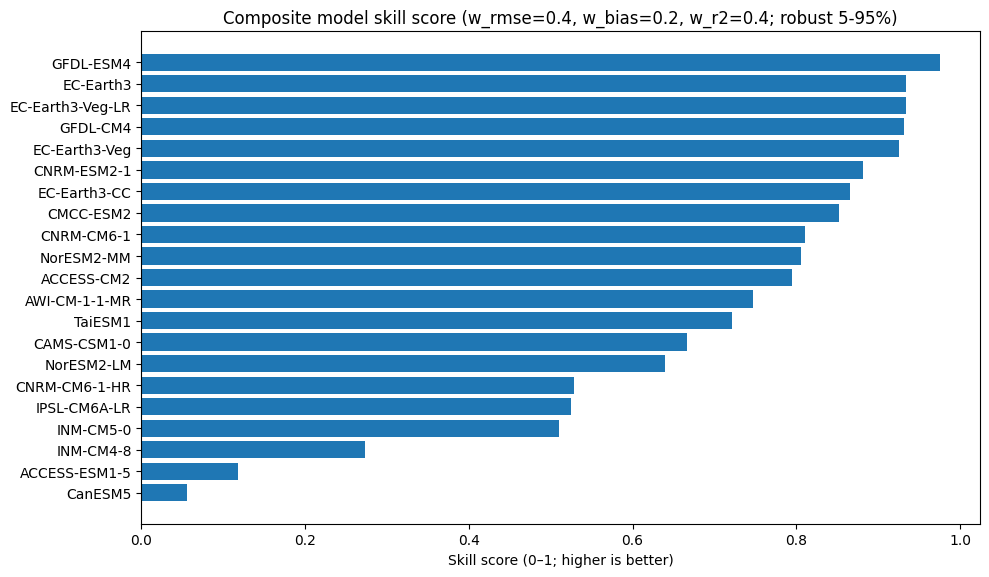

[saved] rank plot: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/passB_skillscore/figS_model_skillscore_ranked.png

Top-10 models by skill score:
           model    crmse      bias       r2  skill_score  skill_rank
       GFDL-ESM4 2.263935 -0.466728 0.895538     0.975715           1
       EC-Earth3 2.307832  0.244311 0.881625     0.934119           2
EC-Earth3-Veg-LR 2.289674  0.090962 0.876655     0.933941           3
        GFDL-CM4 2.239204 -1.143038 0.902572     0.932006           4
   EC-Earth3-Veg 2.305315  0.247498 0.878696     0.925574           5
     CNRM-ESM2-1 2.488720 -0.050690 0.878393     0.881062           6
    EC-Earth3-CC 2.328464  0.889339 0.874984     0.865811           7
       CMCC-ESM2 2.300406  0.670495 0.863242     0.851775           8
      CNRM-CM6-1 2.534559 -0.779489 0.874314     0.810504           9
      NorESM2-MM 2.305018  0.190021 0.838874     0.805956          10


In [9]:
# ============================================================
# PASS B (FROM SCRATCH, CACHE-ONLY)
# 1) Load cached p99(tasmax) maps for all models (Pass A output)
# 2) Regrid Berkeley p99 to each model grid
# 3) Compute metrics over 45S–45N: cRMSE, bias, spatial R^2
# 4) Compute robust composite "skill_score" (0–1) + rank
# 5) Save CSV + table PNG + ranked bar plot
# ============================================================

import os, glob, gc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Colab Drive mount (safe) ----------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ---------------- Paths ----------------
WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"
CACHE_DIR  = f"{OUTPUT_DIR}/p99_cache_hist1980_2014"
FIG_DIR    = f"{OUTPUT_DIR}/passB_skillscore"
os.makedirs(FIG_DIR, exist_ok=True)

BERKELEY_P99_PATH = f"{WORKDIR}/historical_output/tmax_99th_percentile.nc"
BERKELEY_VAR_NAME = "tmax_99th_percentile"  # will fallback if file contains a single var

# Outputs
METRICS_CSV = os.path.join(FIG_DIR, "cmip6_model_metrics_1980_2014_p99_centeredRMSE_with_skillscore.csv")
TABLE_PNG   = os.path.join(FIG_DIR, "table1_metrics_with_skillscore.png")
RANK_PNG    = os.path.join(FIG_DIR, "figS_model_skillscore_ranked.png")

print("[info] WORKDIR   :", WORKDIR)
print("[info] CACHE_DIR :", CACHE_DIR)
print("[info] FIG_DIR   :", FIG_DIR)
print("[info] BERKELEY  :", BERKELEY_P99_PATH)

# ---------------- Region settings ----------------
LAT_MIN, LAT_MAX = -45, 45  # metrics region (your choice)

# ---------------- Skill score settings ----------------
# Weights (pattern emphasized): cRMSE + R^2 are pattern; |bias| is offset
W_RMSE = 0.4
W_R2   = 0.4
W_BIAS = 0.2

# robust scaling bounds (winsorized min-max)
P_LO, P_HI = 5, 95

# ---------------- Helpers ----------------
def normalize_latlon(obj):
    if "latitude" in obj.coords:
        obj = obj.rename({"latitude": "lat"})
    if "longitude" in obj.coords:
        obj = obj.rename({"longitude": "lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords:
        obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra:
        da = da.mean(dim=extra)
    if "lat" in da.coords and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def maybe_K_to_C(da: xr.DataArray) -> xr.DataArray:
    da = da.astype("float32")
    # heuristic: if median looks like Kelvin, convert
    try:
        v = float(da.quantile(0.5).values)
        if np.isfinite(v) and v > 150:
            da = da - 273.15
    except Exception:
        pass
    da.attrs["units"] = "degC"
    return da

def load_berkeley_p99(path, var_expected):
    ds = xr.open_dataset(path)
    if var_expected not in ds:
        vars_in = list(ds.data_vars)
        if len(vars_in) == 1:
            var_expected = vars_in[0]
            print(f"[info] Using sole variable in {os.path.basename(path)}: {var_expected}")
        else:
            raise KeyError(f"{var_expected} not found. Vars: {vars_in}")
    da = normalize_latlon(ds[var_expected])
    da = to_latlon_2d(da)
    da = maybe_K_to_C(da)
    return da

def load_model_cached_p99(nc_path):
    ds = xr.open_dataset(nc_path)
    if "p99_tasmax" in ds:
        da = ds["p99_tasmax"]
    else:
        # fallback if var name differs
        da = ds.to_array().squeeze(drop=True)
    da = to_latlon_2d(da)
    da = maybe_K_to_C(da)
    return da

def calc_spatial_r2(model_da, obs_da):
    m = model_da.values.ravel()
    o = obs_da.values.ravel()
    mask = np.isfinite(m) & np.isfinite(o)
    if mask.sum() < 10:
        return np.nan
    m = m[mask]; o = o[mask]
    mm = m - m.mean()
    oo = o - o.mean()
    denom = np.sqrt((mm**2).sum() * (oo**2).sum())
    if denom == 0:
        return np.nan
    r = (mm * oo).sum() / denom
    return float(r**2)

def calc_metrics_centered_rmse(model_da, obs_da):
    model_da = to_latlon_2d(model_da)
    obs_da   = to_latlon_2d(obs_da)
    diff = model_da - obs_da
    bias = float(diff.mean().values)
    crmse = float((((diff - diff.mean())**2).mean())**0.5)  # centered RMSE
    r2 = calc_spatial_r2(model_da, obs_da)
    return crmse, bias, r2

def robust_minmax(x, p_lo=5, p_hi=95):
    x = np.asarray(x, dtype=float)
    lo = np.nanpercentile(x, p_lo)
    hi = np.nanpercentile(x, p_hi)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = np.nanmin(x); hi = np.nanmax(x)
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            return np.full_like(x, np.nan, dtype=float)
    x_clip = np.clip(x, lo, hi)
    return (x_clip - lo) / (hi - lo)

def add_skill_score(df, w_rmse=0.4, w_bias=0.2, w_r2=0.4, p_lo=5, p_hi=95):
    df = df.copy()
    df["abs_bias"] = df["bias"].abs()

    n_rmse = robust_minmax(df["crmse"].values, p_lo, p_hi)
    n_ab   = robust_minmax(df["abs_bias"].values, p_lo, p_hi)
    n_r2   = robust_minmax(df["r2"].values, p_lo, p_hi)

    # convert to skills (higher = better)
    df["S_rmse"] = 1.0 - n_rmse
    df["S_bias"] = 1.0 - n_ab
    df["S_r2"]   = n_r2

    df["skill_score"] = w_rmse*df["S_rmse"] + w_bias*df["S_bias"] + w_r2*df["S_r2"]
    df["skill_rank"] = df["skill_score"].rank(ascending=False, method="min").astype(int)

    return df

def plot_table_with_skill(df_scored, out_png):
    """
    Make a Table-1 style PNG including skill_score.
    Shading is relative to multi-model MEDIAN (robust benchmark):
      - cRMSE: smaller is better
      - |bias|: smaller is better
      - R^2: larger is better
      - skill_score: larger is better
    """
    d = df_scored.copy()

    # multi-model summaries
    mmm = pd.Series({
        "crmse": d["crmse"].mean(),
        "bias":  d["bias"].mean(),
        "r2":    d["r2"].mean(),
        "skill_score": d["skill_score"].mean(),
    })
    mmm_med = pd.Series({
        "crmse": d["crmse"].median(),
        "bias":  d["bias"].median(),
        "r2":    d["r2"].median(),
        "skill_score": d["skill_score"].median(),
    })

    # assemble table
    d0 = d[["model","crmse","bias","r2","skill_score"]].copy()
    d0 = d0.sort_values("model").reset_index(drop=True)

    d0 = pd.concat([
        d0,
        pd.DataFrame([{"model":"Multi-model mean",   "crmse": mmm["crmse"],     "bias": mmm["bias"],     "r2": mmm["r2"],     "skill_score": mmm["skill_score"]}]),
        pd.DataFrame([{"model":"Multi-model median", "crmse": mmm_med["crmse"], "bias": mmm_med["bias"], "r2": mmm_med["r2"], "skill_score": mmm_med["skill_score"]}]),
    ], ignore_index=True)

    ref_rmse = mmm_med["crmse"]
    ref_absb = abs(mmm_med["bias"])
    ref_r2   = mmm_med["r2"]
    ref_ss   = mmm_med["skill_score"]

    cell_text = []
    for _, r in d0.iterrows():
        cell_text.append([
            r["model"],
            f"{r['crmse']:.2f}",
            f"{r['bias']:+.2f}",
            f"{r['r2']:.3f}",
            f"{r['skill_score']:.3f}",
        ])

    col_labels = ["Model", "cRMSE (°C)", "Bias (°C)", r"Spatial $R^2$", "Skill score"]

    good = "#c6efce"
    bad  = "#f4cccc"
    header = "#d9d9d9"
    summary = "#e6e6e6"

    fig, ax = plt.subplots(figsize=(13, 0.35*len(d0) + 1.6))
    ax.axis("off")
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.2)
    tbl.scale(1.0, 1.25)

    # header
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor(header)
        tbl[0, j].set_text_props(weight="bold")

    # rows
    for i in range(len(d0)):
        r = d0.iloc[i]
        row_idx = i + 1
        is_summary = (r["model"] in ["Multi-model mean", "Multi-model median"])
        for j in range(len(col_labels)):
            cell = tbl[row_idx, j]
            if is_summary:
                cell.set_facecolor(summary)
                cell.set_text_props(weight="bold")
                continue
            if j == 0:
                continue
            if j == 1:
                cell.set_facecolor(good if r["crmse"] <= ref_rmse else bad)
            elif j == 2:
                cell.set_facecolor(good if abs(r["bias"]) <= ref_absb else bad)
            elif j == 3:
                cell.set_facecolor(good if r["r2"] >= ref_r2 else bad)
            elif j == 4:
                cell.set_facecolor(good if r["skill_score"] >= ref_ss else bad)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("[saved] table:", out_png)

def plot_rank_bar(df_scored, out_png):
    d = df_scored.sort_values("skill_score", ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, max(4, 0.28*len(d))))
    plt.barh(d["model"], d["skill_score"])
    plt.gca().invert_yaxis()
    plt.xlabel("Skill score (0–1; higher is better)")
    plt.title(f"Composite model skill score (w_rmse={W_RMSE}, w_bias={W_BIAS}, w_r2={W_R2}; robust {P_LO}-{P_HI}%)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print("[saved] rank plot:", out_png)

# ============================================================
# Main
# ============================================================

cached = sorted(glob.glob(os.path.join(CACHE_DIR, "*_p99_tasmax_hist1980_2014.nc")))
if len(cached) == 0:
    raise RuntimeError(
        f"No cached p99 files found in:\n  {CACHE_DIR}\n\n"
        "This Pass B is cache-only. Run Pass A to create cached p99 maps first."
    )

models = [os.path.basename(p).replace("_p99_tasmax_hist1980_2014.nc", "") for p in cached]
print(f"[info] Cached models found: N={len(models)}")
print("       First few:", models[:10])

berkeley_native = load_berkeley_p99(BERKELEY_P99_PATH, BERKELEY_VAR_NAME)

rows = []
for nc_path, model in zip(cached, models):
    try:
        model_p99 = load_model_cached_p99(nc_path)

        # regrid Berkeley to this model grid
        berkeley_rg = berkeley_native.interp(
            lat=model_p99["lat"], lon=model_p99["lon"], method="linear"
        )

        # metrics domain
        model_lims = model_p99.sel(lat=slice(LAT_MIN, LAT_MAX))
        obs_lims   = berkeley_rg.sel(lat=slice(LAT_MIN, LAT_MAX))

        crmse, bias, r2 = calc_metrics_centered_rmse(model_lims, obs_lims)
        rows.append({"model": model, "crmse": crmse, "bias": bias, "r2": r2})

        print(f"[ok] {model:15s} cRMSE={crmse:5.2f}  Bias={bias:+6.2f}  R2={r2:5.3f}")

        del model_p99, berkeley_rg, model_lims, obs_lims
        gc.collect()

    except Exception as e:
        print(f"[skip] {model}: {e}")
        gc.collect()

df = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
print("[info] Metrics computed for N =", len(df))

# Add skill score + rank
df_scored = add_skill_score(df, w_rmse=W_RMSE, w_bias=W_BIAS, w_r2=W_R2, p_lo=P_LO, p_hi=P_HI)

# Save CSV
df_scored.to_csv(METRICS_CSV, index=False)
print("[saved] metrics+skillscore CSV:", METRICS_CSV)

# Make Table PNG + Rank plot
plot_table_with_skill(df_scored, TABLE_PNG)
plot_rank_bar(df_scored, RANK_PNG)

# quick peek: top 10 by skill
top10 = df_scored.sort_values("skill_score", ascending=False).head(10)[
    ["model","crmse","bias","r2","skill_score","skill_rank"]
]
print("\nTop-10 models by skill score:")
print(top10.to_string(index=False))
